# Data Stimulation

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# SMART HOSPITAL SYNTHETIC DATA - INTERNAL MEDICINE
# Working calendar:
# - Monday to Friday: Morning + Afternoon
# - Saturday: Morning only
# - Remove public holidays
#
# New assumption:
# - Average total patients/day around 750
# - Average booking share around 20%-25%
# - Large day-to-day variation around the average
# =========================================================

np.random.seed(42)

# -----------------------------
# 1. CONFIG
# -----------------------------
start_date = "2024-01-01"
end_date = "2026-03-31"

# -----------------------------
# 2. DEFINE HOLIDAYS
# -----------------------------
holiday_ranges = [
    # 2024
    ("2024-01-01", "2024-01-01"),
    ("2024-02-08", "2024-02-14"),
    ("2024-04-18", "2024-04-18"),
    ("2024-04-30", "2024-04-30"),
    ("2024-05-01", "2024-05-01"),
    ("2024-08-31", "2024-09-03"),

    # 2025
    ("2025-01-01", "2025-01-01"),
    ("2025-01-25", "2025-02-02"),
    ("2025-04-05", "2025-04-07"),
    ("2025-04-30", "2025-05-04"),
    ("2025-08-30", "2025-09-02"),

    # 2026
    ("2026-01-01", "2026-01-04"),
    ("2026-02-14", "2026-02-22"),
]

holiday_dates = set()
for start_h, end_h in holiday_ranges:
    for d in pd.date_range(start_h, end_h, freq="D"):
        holiday_dates.add(pd.Timestamp(d))

# -----------------------------
# 3. CREATE DAILY CALENDAR
# -----------------------------
all_dates = pd.date_range(start=start_date, end=end_date, freq="D")
daily_df = pd.DataFrame({"date": all_dates})

daily_df["day_of_week"] = daily_df["date"].dt.dayofweek  # Monday=0 ... Sunday=6
daily_df["is_holiday"] = daily_df["date"].isin(holiday_dates)

# Working days:
# - Monday to Saturday
# - remove Sunday
# - remove holidays
daily_df = daily_df[
    (daily_df["day_of_week"] <= 5) & (~daily_df["is_holiday"])
].copy()

daily_df["year"] = daily_df["date"].dt.year
daily_df["month"] = daily_df["date"].dt.month
daily_df["day_of_year"] = daily_df["date"].dt.dayofyear

days_from_start = (daily_df["date"] - daily_df["date"].min()).dt.days
daily_df["trend_factor"] = 1 + (days_from_start / days_from_start.max()) * 0.05
# nhẹ: tăng 5% toàn kỳ

# -----------------------------
# 4. DAILY TOTAL PATIENT PATTERN
# -----------------------------
# Chỉnh base để trung bình thực tế toàn kỳ ~750
daily_base = 760

weekday_factor = daily_df["day_of_week"].map({
    0: 1.18,  # Monday
    1: 1.10,  # Tuesday
    2: 1.03,  # Wednesday
    3: 0.95,  # Thursday
    4: 0.88,  # Friday
    5: 0.62   # Saturday morning-only day
})

month_factor = daily_df["month"].map({
    1: 1.03,
    2: 0.90,
    3: 1.00,
    4: 0.98,
    5: 1.00,
    6: 1.03,
    7: 1.08,
    8: 1.10,
    9: 1.06,
    10: 1.01,
    11: 1.00,
    12: 1.02
})

smooth_seasonality = 1 + 0.04 * np.sin(2 * np.pi * daily_df["day_of_year"] / 365.25)

# dao động ngày lớn quanh mức trung bình
daily_noise = np.random.normal(loc=1.0, scale=0.15, size=len(daily_df))
daily_noise = np.clip(daily_noise, 0.68, 1.38)

daily_df["daily_total_patients"] = np.round(
    daily_base
    * daily_df["trend_factor"]
    * weekday_factor
    * month_factor
    * smooth_seasonality
    * daily_noise
).astype(int)

daily_df["daily_total_patients"] = daily_df["daily_total_patients"].clip(lower=350, upper=1200)

# -----------------------------
# 5. DAILY BOOKING SHARE PATTERN
# -----------------------------
booking_share_base = 0.225

booking_weekday_adj = daily_df["day_of_week"].map({
    0: 0.015,
    1: 0.010,
    2: 0.000,
    3: -0.005,
    4: -0.010,
    5: -0.015
})

booking_month_adj = daily_df["month"].map({
    1: 0.000,
    2: -0.015,
    3: 0.000,
    4: 0.000,
    5: 0.000,
    6: 0.005,
    7: 0.010,
    8: 0.010,
    9: 0.005,
    10: 0.000,
    11: 0.000,
    12: 0.000
})

booking_trend_adj = 0.015 * (days_from_start / days_from_start.max())
booking_share_noise = np.random.normal(loc=0.0, scale=0.035, size=len(daily_df))

daily_df["booking_share"] = (
    booking_share_base
    + booking_weekday_adj
    + booking_month_adj
    + booking_trend_adj
    + booking_share_noise
)

daily_df["booking_share"] = daily_df["booking_share"].clip(0.10, 0.36)

daily_df["daily_appointments_booked"] = np.round(
    daily_df["daily_total_patients"] * daily_df["booking_share"]
).astype(int)

# luôn chừa walk-in
daily_df["daily_appointments_booked"] = np.minimum(
    daily_df["daily_appointments_booked"],
    daily_df["daily_total_patients"] - 25
)
daily_df["daily_walk_in_patients"] = (
    daily_df["daily_total_patients"] - daily_df["daily_appointments_booked"]
)

# -----------------------------
# 6. SPLIT INTO SHIFTS
# -----------------------------
# Mon-Fri: Morning + Afternoon
# Sat: Morning only

morning_share_weekday = np.random.normal(loc=0.60, scale=0.06, size=len(daily_df))
morning_share_weekday = np.clip(morning_share_weekday, 0.48, 0.72)

daily_df["morning_share"] = np.where(
    daily_df["day_of_week"] == 5,
    1.0,
    morning_share_weekday
)

daily_df["morning_total"] = np.round(
    daily_df["daily_total_patients"] * daily_df["morning_share"]
).astype(int)
daily_df["afternoon_total"] = daily_df["daily_total_patients"] - daily_df["morning_total"]

morning_booking_share = np.random.normal(loc=0.62, scale=0.07, size=len(daily_df))
morning_booking_share = np.clip(morning_booking_share, 0.45, 0.78)

daily_df["morning_booking_share"] = np.where(
    daily_df["day_of_week"] == 5,
    1.0,
    morning_booking_share
)

daily_df["morning_booked"] = np.round(
    daily_df["daily_appointments_booked"] * daily_df["morning_booking_share"]
).astype(int)
daily_df["afternoon_booked"] = daily_df["daily_appointments_booked"] - daily_df["morning_booked"]

# safety checks
daily_df["morning_booked"] = np.minimum(
    daily_df["morning_booked"],
    np.maximum(daily_df["morning_total"] - 5, 0)
)
daily_df["morning_booked"] = np.maximum(daily_df["morning_booked"], 0)

daily_df["afternoon_booked"] = daily_df["daily_appointments_booked"] - daily_df["morning_booked"]
daily_df["afternoon_booked"] = np.minimum(
    daily_df["afternoon_booked"],
    np.maximum(daily_df["afternoon_total"] - 5, 0)
)
daily_df["afternoon_booked"] = np.maximum(daily_df["afternoon_booked"], 0)

# -----------------------------
# 7. RESHAPE TO SHIFT LEVEL
# -----------------------------
morning_df = daily_df[["date", "morning_booked", "morning_total"]].copy()
morning_df["shift"] = "Morning"
morning_df = morning_df.rename(columns={
    "morning_booked": "appointments_booked",
    "morning_total": "total_patients"
})

afternoon_df = daily_df[["date", "afternoon_booked", "afternoon_total", "day_of_week"]].copy()
afternoon_df["shift"] = "Afternoon"
afternoon_df = afternoon_df.rename(columns={
    "afternoon_booked": "appointments_booked",
    "afternoon_total": "total_patients"
})

# bỏ chiều thứ 7
afternoon_df = afternoon_df[afternoon_df["day_of_week"] != 5].copy()
afternoon_df = afternoon_df.drop(columns=["day_of_week"])

final_df = pd.concat([morning_df, afternoon_df], ignore_index=True)

shift_order_map = {"Morning": 0, "Afternoon": 1}
final_df["shift_order"] = final_df["shift"].map(shift_order_map)

final_df = final_df.sort_values(["date", "shift_order"]).reset_index(drop=True)
final_df = final_df[["date", "shift", "appointments_booked", "total_patients"]]

# -----------------------------
# 8. CHECK TABLES
# -----------------------------
daily_check = (
    final_df.groupby("date", as_index=False)[["appointments_booked", "total_patients"]]
    .sum()
)
daily_check["booking_share"] = daily_check["appointments_booked"] / daily_check["total_patients"]
daily_check["weekday_name"] = pd.to_datetime(daily_check["date"]).dt.day_name()

shift_check = (
    final_df.groupby("shift", as_index=False)[["appointments_booked", "total_patients"]]
    .mean()
)

# -----------------------------
# 9. SAVE
# -----------------------------
final_df.to_csv("hospital_forecast_data_avg750.csv", index=False)
daily_check.to_csv("hospital_forecast_daily_check_avg750.csv", index=False)

# -----------------------------
# 10. QUICK SUMMARY
# -----------------------------
print("Shift-level data shape:", final_df.shape)
print(final_df.head(10))
print(final_df.tail(10))

print("\n===== DAILY SUMMARY =====")
print(daily_check[["appointments_booked", "total_patients", "booking_share"]].describe().round(3))

print("\nAverage daily total patients:", round(daily_check["total_patients"].mean(), 2))
print("Median daily total patients :", round(daily_check["total_patients"].median(), 2))
print("Average booking share       :", round(daily_check["booking_share"].mean(), 3))
print("Median booking share        :", round(daily_check["booking_share"].median(), 3))

print("\n===== SHIFT SUMMARY =====")
print(shift_check.round(2))

print("\n===== WORKING DAY COUNTS =====")
print(daily_check["weekday_name"].value_counts())

print("\nSaved files:")
print("- hospital_forecast_data_avg750.csv")
print("- hospital_forecast_daily_check_avg750.csv")

Shift-level data shape: (1221, 4)
        date      shift  appointments_booked  total_patients
0 2024-01-02    Morning                  137             489
1 2024-01-02  Afternoon                   58             438
2 2024-01-03    Morning                  121             503
3 2024-01-03  Afternoon                   60             288
4 2024-01-04    Morning                  112             566
5 2024-01-04  Afternoon                   61             252
6 2024-01-05    Morning                  158             571
7 2024-01-05  Afternoon                   69             278
8 2024-01-06    Morning                   55             470
9 2024-01-08    Morning                  139             618
           date      shift  appointments_booked  total_patients
1211 2026-03-25  Afternoon                   93             314
1212 2026-03-26    Morning                  141             486
1213 2026-03-26  Afternoon                   53             285
1214 2026-03-27    Morning             

In [ ]:
final_df.to_excel("hospital_forecast_data_avg750.xlsx", index=False)

# EDA

1. BASIC OVERVIEW
Shape: (1221, 4)

Columns:
['date', 'shift', 'appointments_booked', 'total_patients']

Head:
        date      shift  appointments_booked  total_patients
0 2024-01-02    Morning                  137             489
1 2024-01-02  Afternoon                   58             438
2 2024-01-03    Morning                  121             503
3 2024-01-03  Afternoon                   60             288
4 2024-01-04    Morning                  112             566

Tail:
           date      shift  appointments_booked  total_patients
1216 2026-03-28    Morning                   74             472
1217 2026-03-30    Morning                  124             631
1218 2026-03-30  Afternoon                   92             343
1219 2026-03-31    Morning                  139             541
1220 2026-03-31  Afternoon                   66             297

Dtypes:
date                   datetime64[ns]
shift                          object
appointments_booked             int64
total_pat

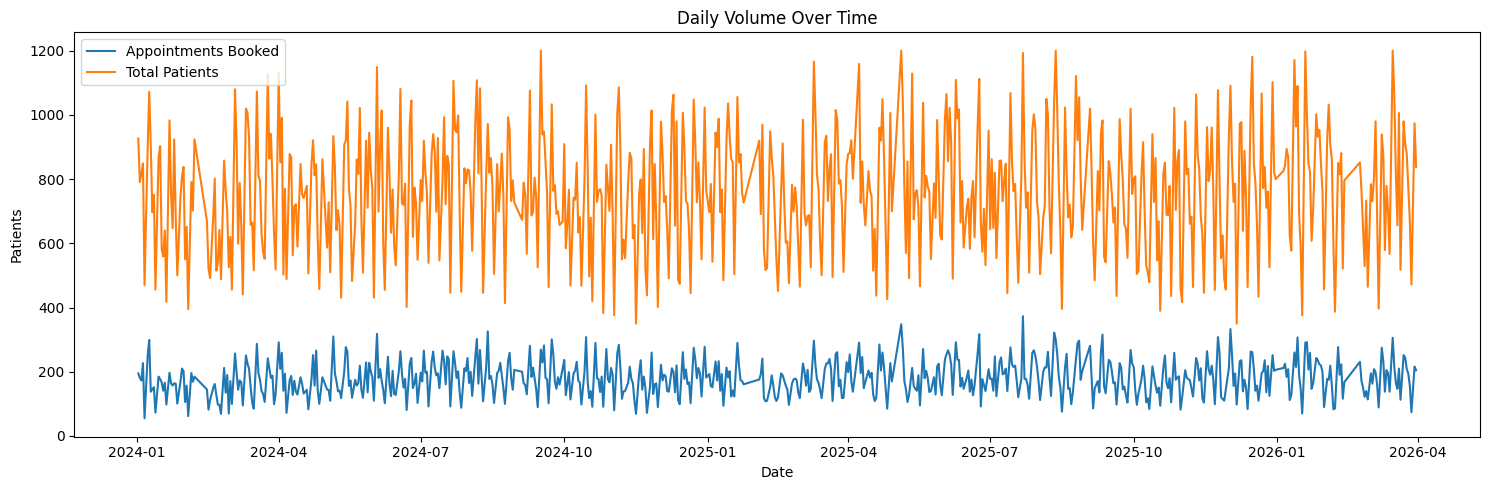

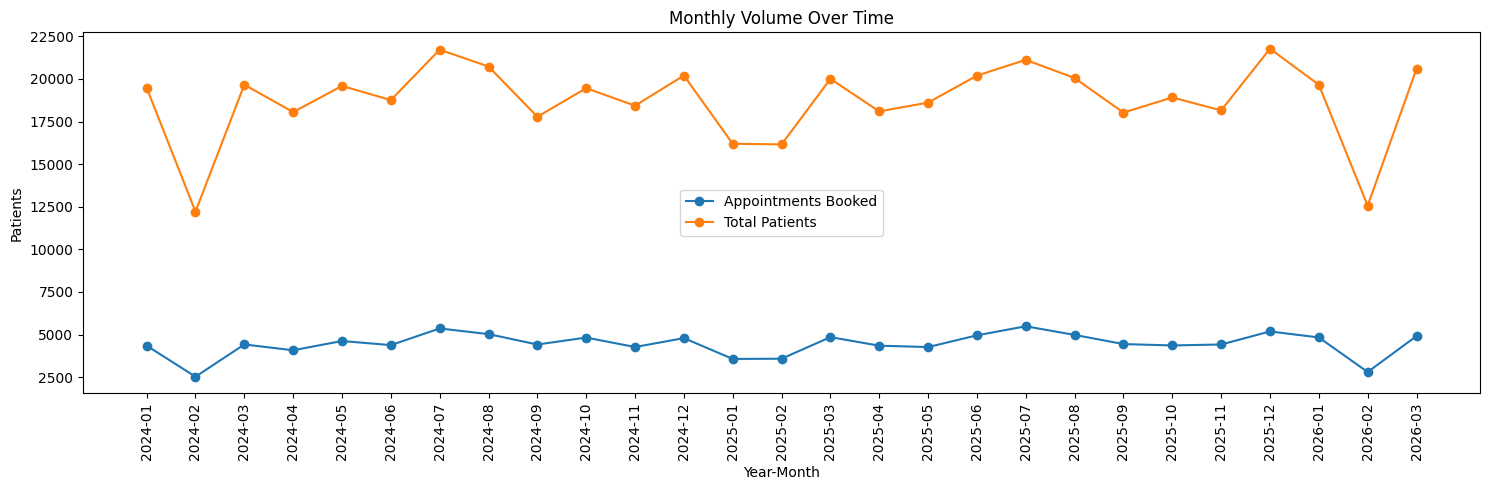

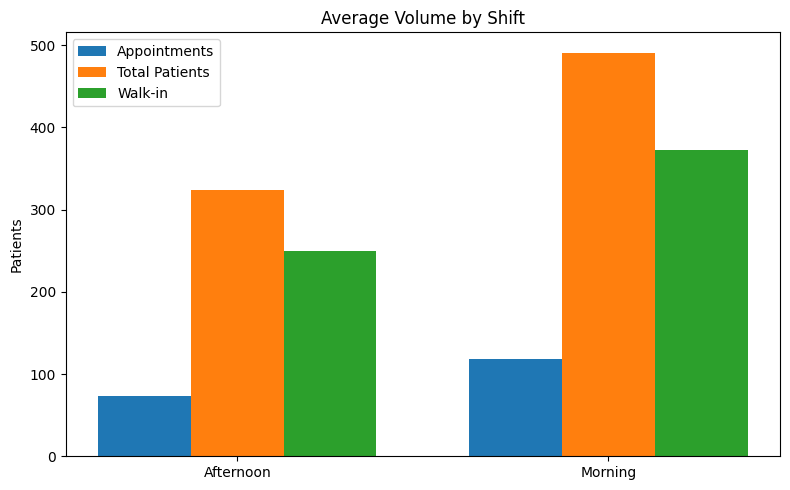

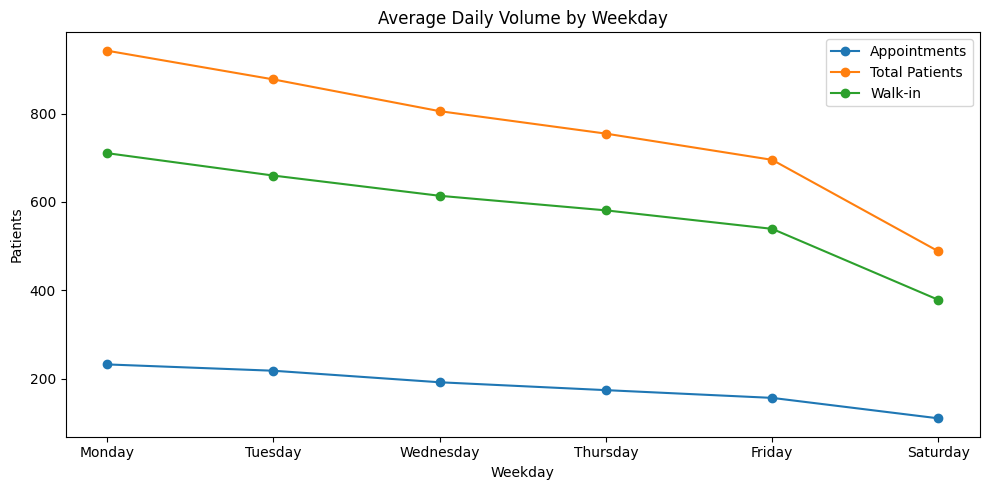

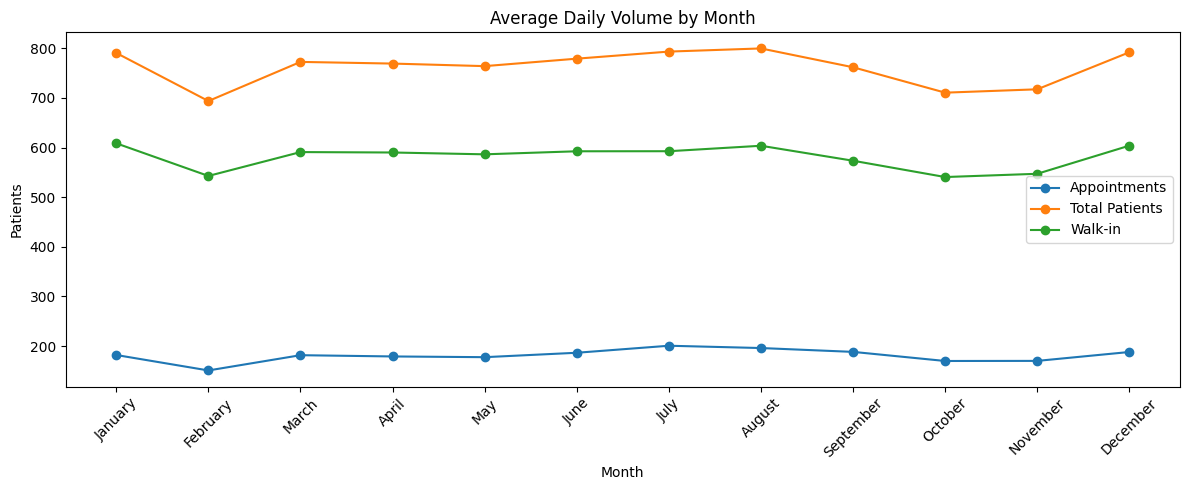

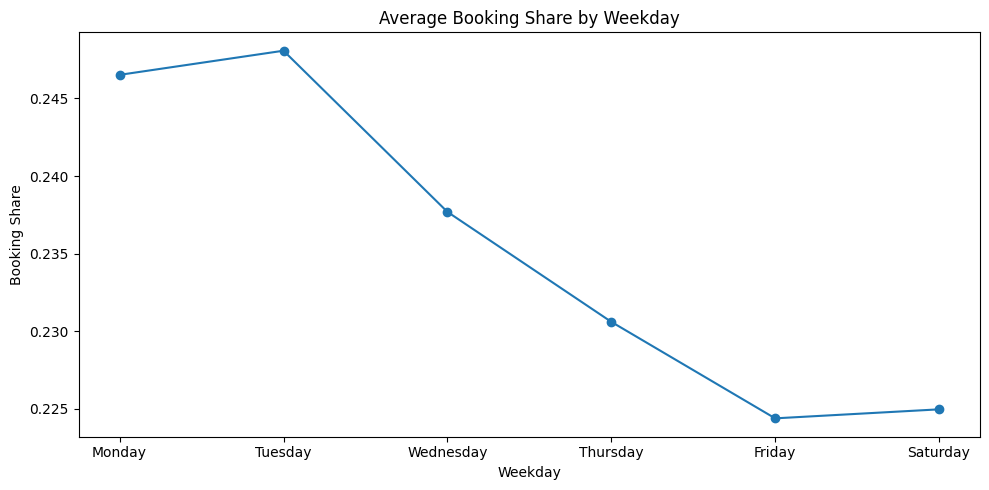

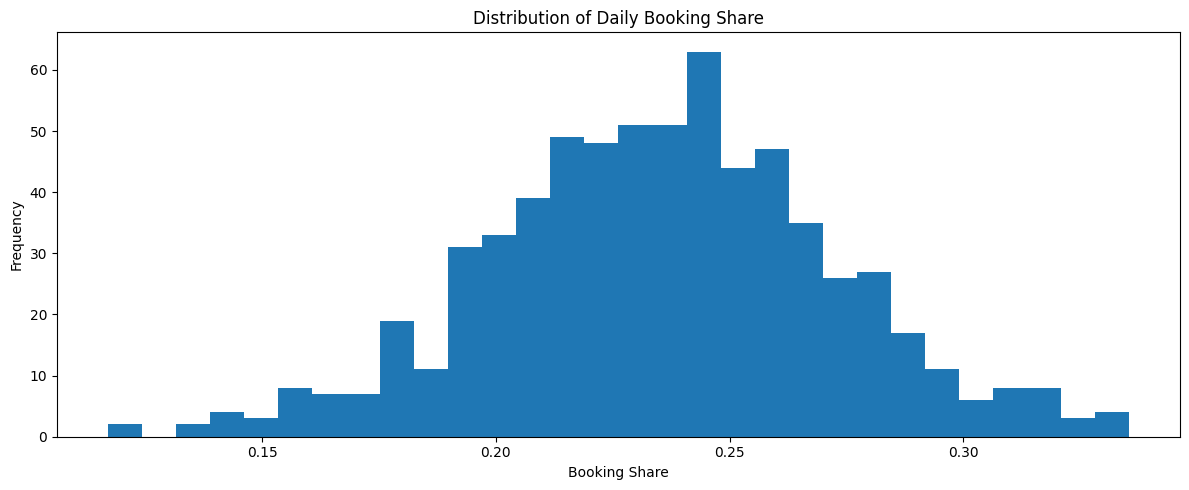

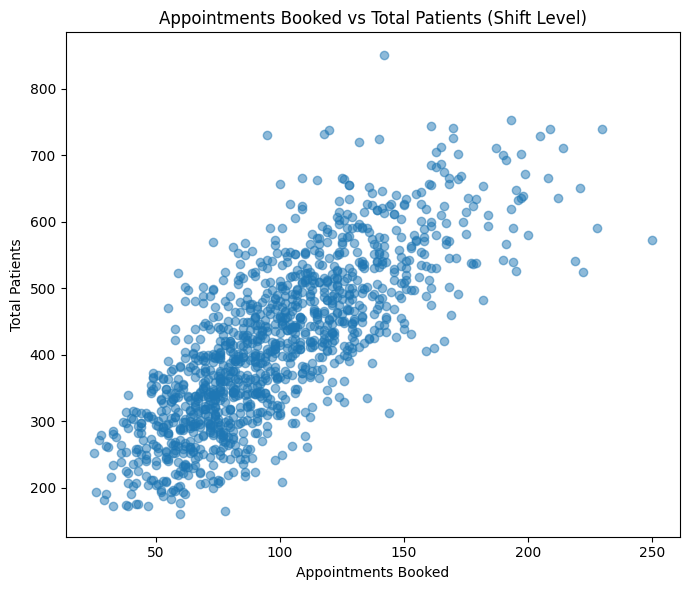

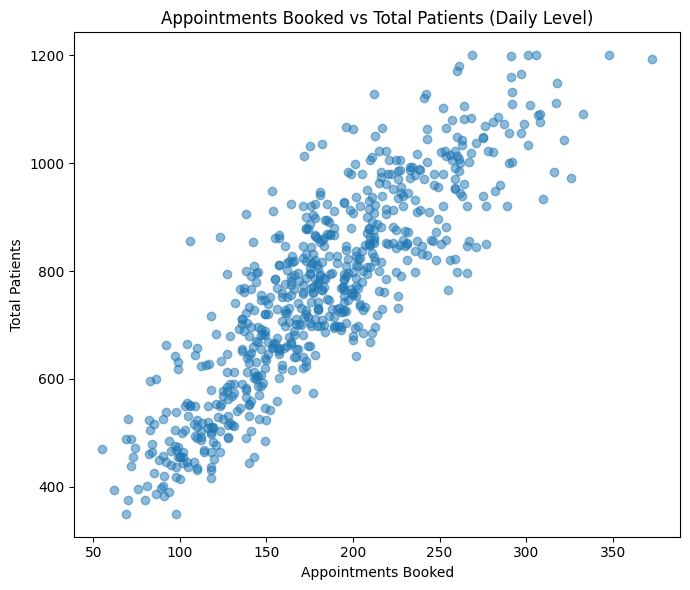

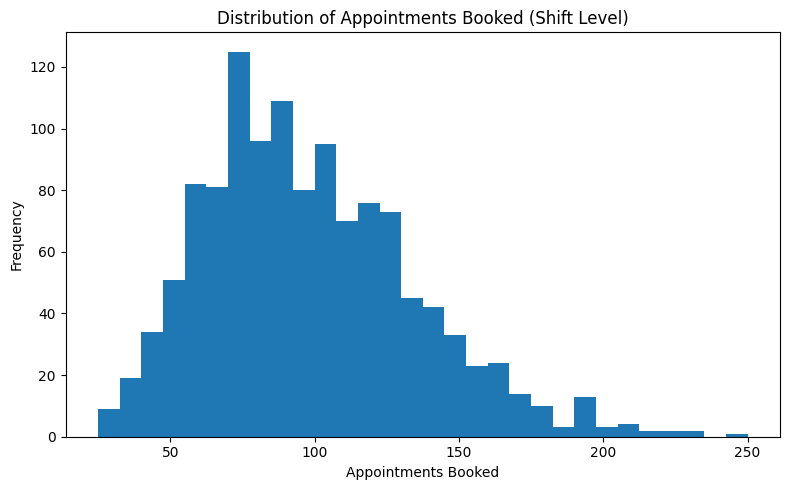

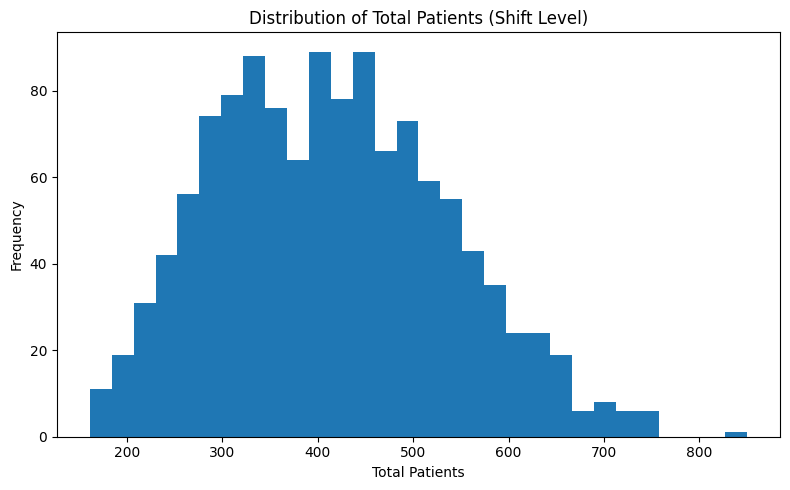

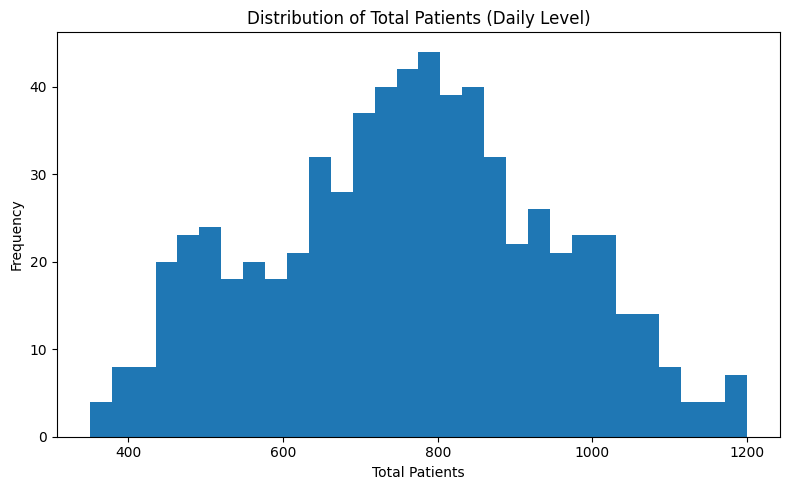


7. TOP / BOTTOM DAYS

Top 10 busiest days:
          date weekday_name  appointments_booked  total_patients  \
478 2025-08-12      Tuesday                  301            1200   
650 2026-03-16       Monday                  306            1200   
209 2024-09-16       Monday                  269            1200   
393 2025-05-05       Monday                  348            1200   
609 2026-01-19       Monday                  291            1198   
460 2025-07-22      Tuesday                  373            1193   
583 2025-12-16      Tuesday                  261            1181   
603 2026-01-12       Monday                  260            1171   
351 2025-03-10       Monday                  297            1166   
374 2025-04-08      Tuesday                  291            1159   

     walk_in_patients  booking_share  
478               899       0.250833  
650               894       0.255000  
209               931       0.224167  
393               852       0.290000  
609         

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# EDA - SMART HOSPITAL DATA
# File: hospital_forecast_data_avg750.csv
# ============================================

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("hospital_forecast_data_avg750.csv")
df["date"] = pd.to_datetime(df["date"])

print("=" * 100)
print("1. BASIC OVERVIEW")
print("=" * 100)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nHead:")
print(df.head())

print("\nTail:")
print(df.tail())

print("\nDtypes:")
print(df.dtypes)

# -----------------------------
# 2. DATA QUALITY CHECK
# -----------------------------
print("\n" + "=" * 100)
print("2. DATA QUALITY CHECK")
print("=" * 100)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicated rows:", df.duplicated().sum())
print("Duplicated by date + shift:", df.duplicated(subset=["date", "shift"]).sum())

print("\nUnique shifts:")
print(df["shift"].unique())

print("\nDate range:")
print(df["date"].min(), "->", df["date"].max())

# -----------------------------
# 3. CREATE EDA FEATURES
# -----------------------------
df["day_of_week"] = df["date"].dt.dayofweek
df["weekday_name"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["year"] = df["date"].dt.year
df["year_month"] = df["date"].dt.to_period("M").astype(str)

# proxy walk-in
df["walk_in_patients"] = df["total_patients"] - df["appointments_booked"]

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# -----------------------------
# 4. CHECK WORKING CALENDAR LOGIC
# -----------------------------
print("\n" + "=" * 100)
print("3. CHECK WORKING CALENDAR LOGIC")
print("=" * 100)

daily_shift_check = df.groupby("date", as_index=False).agg(
    n_shifts=("shift", "count"),
    shifts=("shift", lambda x: ", ".join(sorted(x)))
)
daily_shift_check["weekday_name"] = pd.to_datetime(daily_shift_check["date"]).dt.day_name()

print("\nShift count distribution:")
print(daily_shift_check["n_shifts"].value_counts().sort_index())

print("\nSample Saturday rows:")
print(daily_shift_check[daily_shift_check["weekday_name"] == "Saturday"].head(10))

print("\nSample rows with only 1 shift:")
print(daily_shift_check[daily_shift_check["n_shifts"] == 1].head(10))

print("\nAny Sunday in data?:", (df["weekday_name"] == "Sunday").sum())

# -----------------------------
# 5. DESCRIPTIVE STATISTICS
# -----------------------------
print("\n" + "=" * 100)
print("4. DESCRIPTIVE STATISTICS")
print("=" * 100)

print("\nNumeric summary:")
print(df[["appointments_booked", "total_patients", "walk_in_patients"]].describe().round(2))

print("\nCorrelation:")
print(df[["appointments_booked", "total_patients", "walk_in_patients"]].corr().round(3))

# -----------------------------
# 6. DAILY SUMMARY
# -----------------------------
daily_df = (
    df.groupby("date", as_index=False)[["appointments_booked", "total_patients", "walk_in_patients"]]
    .sum()
)

daily_df["booking_share"] = daily_df["appointments_booked"] / daily_df["total_patients"]
daily_df["weekday_name"] = pd.to_datetime(daily_df["date"]).dt.day_name()
daily_df["month"] = pd.to_datetime(daily_df["date"]).dt.month
daily_df["month_name"] = pd.to_datetime(daily_df["date"]).dt.month_name()
daily_df["year"] = pd.to_datetime(daily_df["date"]).dt.year
daily_df["year_month"] = pd.to_datetime(daily_df["date"]).dt.to_period("M").astype(str)

print("\n" + "=" * 100)
print("5. DAILY SUMMARY")
print("=" * 100)

print("\nDaily total patients summary:")
print(daily_df["total_patients"].describe().round(2))

print("\nDaily booking share summary:")
print(daily_df["booking_share"].describe().round(3))

print("\nAverage daily total patients:", round(daily_df["total_patients"].mean(), 2))
print("Median daily total patients :", round(daily_df["total_patients"].median(), 2))
print("Average booking share       :", round(daily_df["booking_share"].mean(), 3))
print("Median booking share        :", round(daily_df["booking_share"].median(), 3))

# -----------------------------
# 7. SUMMARY TABLES
# -----------------------------
print("\n" + "=" * 100)
print("6. SUMMARY TABLES")
print("=" * 100)

summary_by_shift = (
    df.groupby("shift")[["appointments_booked", "total_patients", "walk_in_patients"]]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)
print("\nSummary by shift:")
print(summary_by_shift)

summary_by_weekday = (
    daily_df.groupby("weekday_name")[["appointments_booked", "total_patients", "walk_in_patients", "booking_share"]]
    .mean()
    .reindex(weekday_order)
    .round(2)
)
print("\nAverage by weekday:")
print(summary_by_weekday)

summary_by_month = (
    daily_df.groupby("month_name")[["appointments_booked", "total_patients", "walk_in_patients", "booking_share"]]
    .mean()
    .reindex(month_order)
    .round(2)
)
print("\nAverage by month:")
print(summary_by_month)

summary_by_year = (
    daily_df.groupby("year")[["appointments_booked", "total_patients", "walk_in_patients", "booking_share"]]
    .mean()
    .round(2)
)
print("\nAverage by year:")
print(summary_by_year)

# -----------------------------
# 8. MONTHLY AGGREGATION
# -----------------------------
monthly_df = (
    daily_df.groupby("year_month", as_index=False)[["appointments_booked", "total_patients", "walk_in_patients"]]
    .sum()
)

# -----------------------------
# 9. PLOTS - DAILY TREND
# -----------------------------
plt.figure(figsize=(15, 5))
plt.plot(daily_df["date"], daily_df["appointments_booked"], label="Appointments Booked")
plt.plot(daily_df["date"], daily_df["total_patients"], label="Total Patients")
plt.title("Daily Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Patients")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 10. PLOTS - MONTHLY TREND
# -----------------------------
plt.figure(figsize=(15, 5))
plt.plot(monthly_df["year_month"], monthly_df["appointments_booked"], marker="o", label="Appointments Booked")
plt.plot(monthly_df["year_month"], monthly_df["total_patients"], marker="o", label="Total Patients")
plt.title("Monthly Volume Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Patients")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 11. SHIFT ANALYSIS
# -----------------------------
shift_avg = (
    df.groupby("shift", as_index=False)[["appointments_booked", "total_patients", "walk_in_patients"]]
    .mean()
)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(shift_avg["shift"]))
width = 0.25

ax.bar(x - width, shift_avg["appointments_booked"], width, label="Appointments")
ax.bar(x, shift_avg["total_patients"], width, label="Total Patients")
ax.bar(x + width, shift_avg["walk_in_patients"], width, label="Walk-in")

ax.set_xticks(x)
ax.set_xticklabels(shift_avg["shift"])
ax.set_title("Average Volume by Shift")
ax.set_ylabel("Patients")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 12. WEEKDAY ANALYSIS
# -----------------------------
weekday_avg = (
    daily_df.groupby("weekday_name", as_index=False)[["appointments_booked", "total_patients", "walk_in_patients"]]
    .mean()
)
weekday_avg["weekday_name"] = pd.Categorical(
    weekday_avg["weekday_name"], categories=weekday_order, ordered=True
)
weekday_avg = weekday_avg.sort_values("weekday_name")

plt.figure(figsize=(10, 5))
plt.plot(weekday_avg["weekday_name"], weekday_avg["appointments_booked"], marker="o", label="Appointments")
plt.plot(weekday_avg["weekday_name"], weekday_avg["total_patients"], marker="o", label="Total Patients")
plt.plot(weekday_avg["weekday_name"], weekday_avg["walk_in_patients"], marker="o", label="Walk-in")
plt.title("Average Daily Volume by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Patients")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 13. MONTH ANALYSIS
# -----------------------------
month_avg = (
    daily_df.groupby("month_name", as_index=False)[["appointments_booked", "total_patients", "walk_in_patients"]]
    .mean()
)
month_avg["month_name"] = pd.Categorical(
    month_avg["month_name"], categories=month_order, ordered=True
)
month_avg = month_avg.sort_values("month_name")

plt.figure(figsize=(12, 5))
plt.plot(month_avg["month_name"], month_avg["appointments_booked"], marker="o", label="Appointments")
plt.plot(month_avg["month_name"], month_avg["total_patients"], marker="o", label="Total Patients")
plt.plot(month_avg["month_name"], month_avg["walk_in_patients"], marker="o", label="Walk-in")
plt.title("Average Daily Volume by Month")
plt.xlabel("Month")
plt.ylabel("Patients")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 14. BOOKING SHARE ANALYSIS
# -----------------------------
weekday_booking_share = (
    daily_df.groupby("weekday_name", as_index=False)["booking_share"]
    .mean()
)
weekday_booking_share["weekday_name"] = pd.Categorical(
    weekday_booking_share["weekday_name"], categories=weekday_order, ordered=True
)
weekday_booking_share = weekday_booking_share.sort_values("weekday_name")

plt.figure(figsize=(10, 5))
plt.plot(weekday_booking_share["weekday_name"], weekday_booking_share["booking_share"], marker="o")
plt.title("Average Booking Share by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Booking Share")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.hist(daily_df["booking_share"], bins=30)
plt.title("Distribution of Daily Booking Share")
plt.xlabel("Booking Share")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------------
# 15. APPOINTMENTS VS TOTAL
# -----------------------------
plt.figure(figsize=(7, 6))
plt.scatter(df["appointments_booked"], df["total_patients"], alpha=0.5)
plt.title("Appointments Booked vs Total Patients (Shift Level)")
plt.xlabel("Appointments Booked")
plt.ylabel("Total Patients")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(daily_df["appointments_booked"], daily_df["total_patients"], alpha=0.5)
plt.title("Appointments Booked vs Total Patients (Daily Level)")
plt.xlabel("Appointments Booked")
plt.ylabel("Total Patients")
plt.tight_layout()
plt.show()

# -----------------------------
# 16. DISTRIBUTIONS
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["appointments_booked"], bins=30)
plt.title("Distribution of Appointments Booked (Shift Level)")
plt.xlabel("Appointments Booked")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["total_patients"], bins=30)
plt.title("Distribution of Total Patients (Shift Level)")
plt.xlabel("Total Patients")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(daily_df["total_patients"], bins=30)
plt.title("Distribution of Total Patients (Daily Level)")
plt.xlabel("Total Patients")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------------
# 17. TOP / BOTTOM DAYS
# -----------------------------
print("\n" + "=" * 100)
print("7. TOP / BOTTOM DAYS")
print("=" * 100)

print("\nTop 10 busiest days:")
print(
    daily_df.sort_values("total_patients", ascending=False)[
        ["date", "weekday_name", "appointments_booked", "total_patients", "walk_in_patients", "booking_share"]
    ].head(10)
)

print("\nTop 10 lowest-volume days:")
print(
    daily_df.sort_values("total_patients", ascending=True)[
        ["date", "weekday_name", "appointments_booked", "total_patients", "walk_in_patients", "booking_share"]
    ].head(10)
)

# -----------------------------
# 18. SAVE EDA TABLES
# -----------------------------
summary_by_weekday.to_csv("eda_avg750_summary_by_weekday.csv")
summary_by_month.to_csv("eda_avg750_summary_by_month.csv")
summary_by_year.to_csv("eda_avg750_summary_by_year.csv")
daily_df.to_csv("eda_avg750_daily_summary.csv", index=False)
monthly_df.to_csv("eda_avg750_monthly_summary.csv", index=False)

print("\nSaved files:")
print("- eda_avg750_summary_by_weekday.csv")
print("- eda_avg750_summary_by_month.csv")
print("- eda_avg750_summary_by_year.csv")
print("- eda_avg750_daily_summary.csv")
print("- eda_avg750_monthly_summary.csv")

# Model Implementation & Evaluation

## SARIMAX

DATA OVERVIEW
Shape: (1221, 5)
        date      shift  appointments_booked  total_patients  shift_order
0 2024-01-02    Morning                  137             489            0
1 2024-01-02  Afternoon                   58             438            1
2 2024-01-03    Morning                  121             503            0
3 2024-01-03  Afternoon                   60             288            1
4 2024-01-04    Morning                  112             566            0
           date      shift  appointments_booked  total_patients  shift_order
1216 2026-03-28    Morning                   74             472            0
1217 2026-03-30    Morning                  124             631            0
1218 2026-03-30  Afternoon                   92             343            1
1219 2026-03-31    Morning                  139             541            0
1220 2026-03-31  Afternoon                   66             297            1

Train size: 1173
Test size : 48

SARIMAX MODEL SUMMARY
       

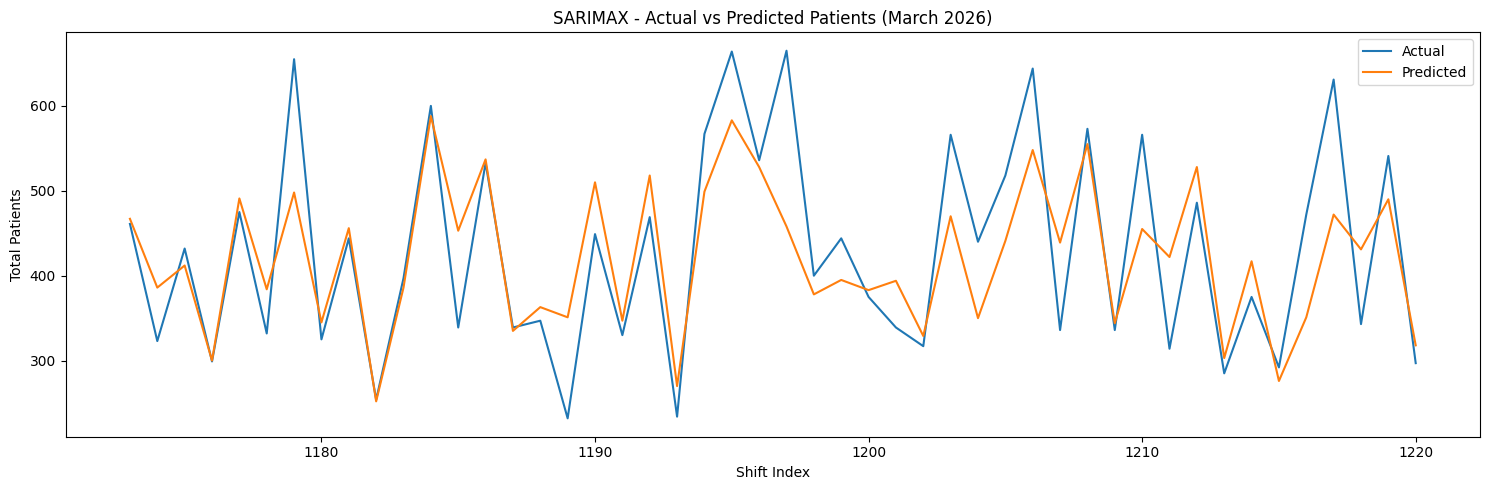

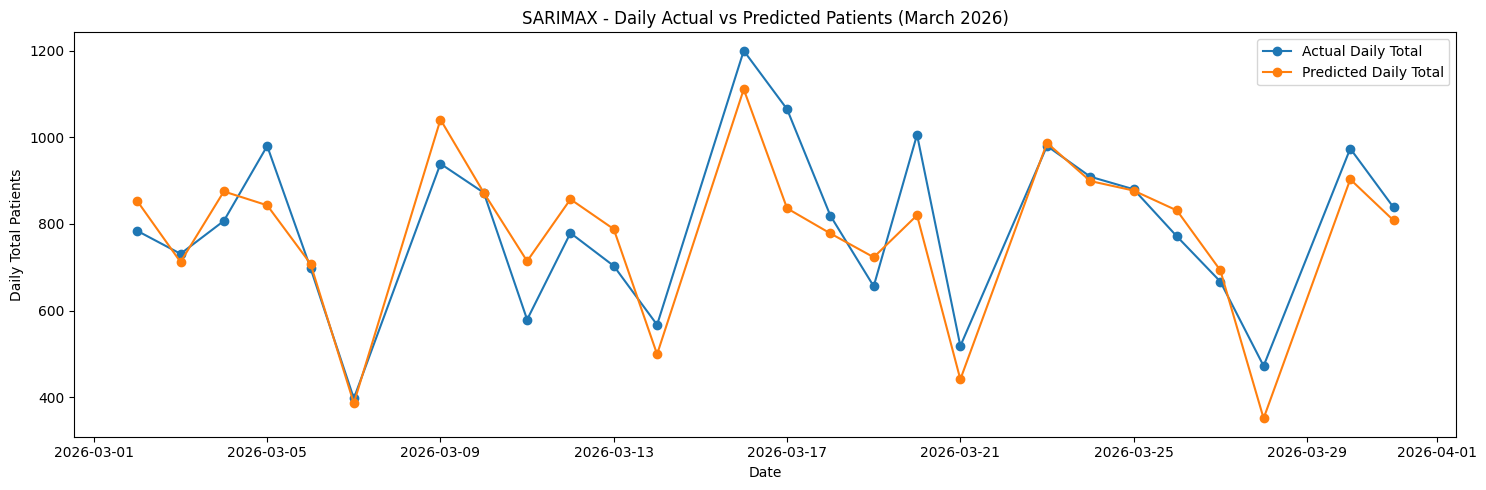

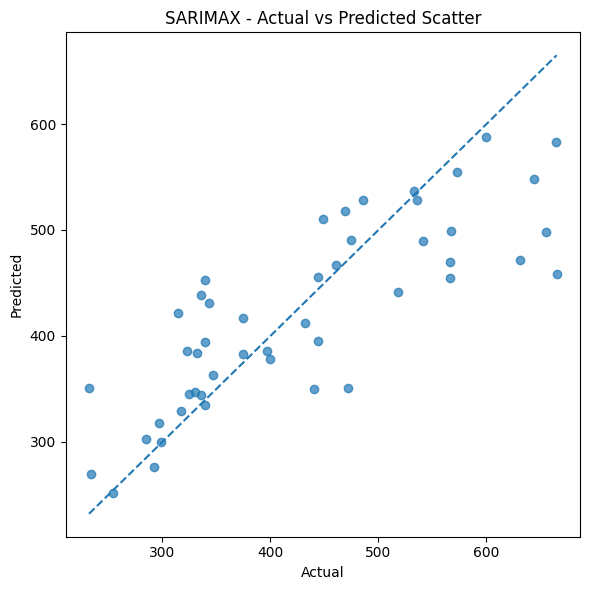


DEMO PREDICTIONS - SARIMAX
Case 1:
479
216
193

Case 2 (booking tăng):
550

APRIL 2026 FORECAST SAMPLE
         date      shift  appointments_booked  predicted_total_patients
0  2026-04-01    Morning                  170                       NaN
1  2026-04-01  Afternoon                  120                       NaN
2  2026-04-02    Morning                  170                       NaN
3  2026-04-02  Afternoon                  120                       NaN
4  2026-04-03    Morning                  170                       NaN
5  2026-04-03  Afternoon                  120                       NaN
6  2026-04-04    Morning                  170                       NaN
7  2026-04-06    Morning                  170                       NaN
8  2026-04-06  Afternoon                  120                       NaN
9  2026-04-07    Morning                  170                       NaN
10 2026-04-07  Afternoon                  120                       NaN
11 2026-04-08    Morning        

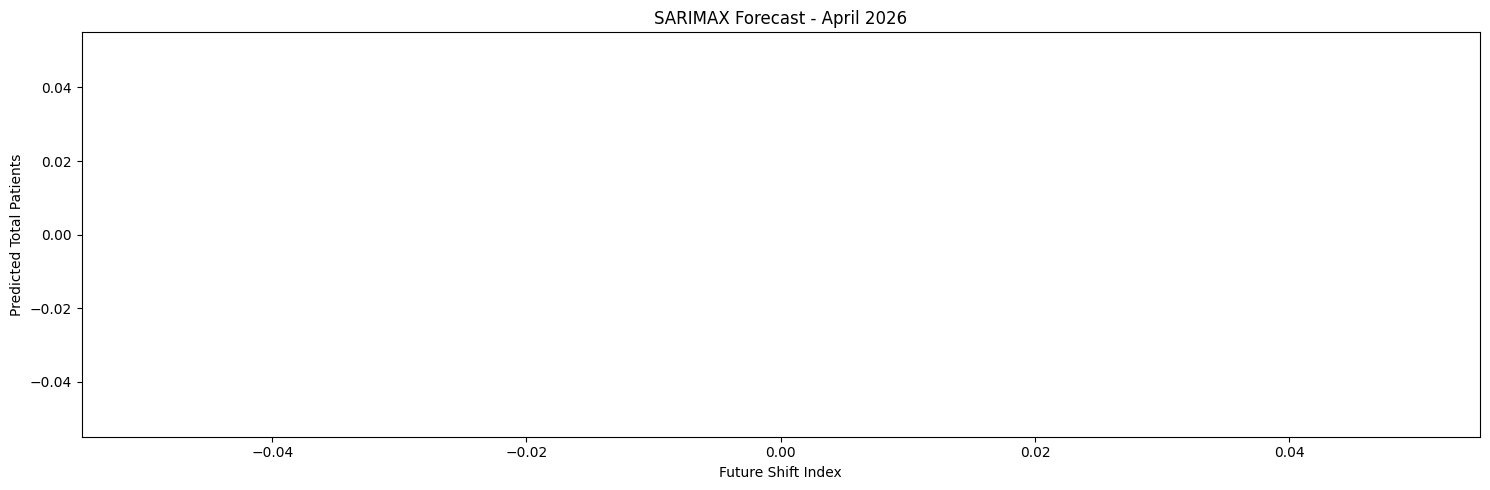


Saved files:
- sarimax_test_predictions_avg750.csv
- sarimax_metrics_avg750.csv
- sarimax_forecast_april_2026_avg750.csv


In [ ]:
# ============================================
# SARIMAX BASELINE - SMART HOSPITAL
# File: hospital_forecast_data_avg750.csv
# Target: total_patients
# Exogenous: appointments_booked
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("hospital_forecast_data_avg750.csv")
df["date"] = pd.to_datetime(df["date"])

shift_order_map = {"Morning": 0, "Afternoon": 1}
df["shift_order"] = df["shift"].map(shift_order_map)

df = df.sort_values(["date", "shift_order"]).reset_index(drop=True)

print("=" * 80)
print("DATA OVERVIEW")
print("=" * 80)
print("Shape:", df.shape)
print(df.head())
print(df.tail())

# =========================
# 2. OPTIONAL: BUILD A SEQUENTIAL INDEX
# =========================
# SARIMAX only needs the correct order.
# We keep a sequential step index for clarity.
df["time_step"] = np.arange(len(df))

# =========================
# 3. TRAIN / TEST SPLIT
# =========================
train_df = df[df["date"] < "2026-03-01"].copy()
test_df = df[(df["date"] >= "2026-03-01") & (df["date"] <= "2026-03-31")].copy()

y_train = train_df["total_patients"]
X_train = train_df[["appointments_booked"]]

y_test = test_df["total_patients"]
X_test = test_df[["appointments_booked"]]

print("\nTrain size:", len(train_df))
print("Test size :", len(test_df))

# =========================
# 4. FIT SARIMAX
# =========================
# Suggested seasonal period:
# 1 week ~ 11 shift steps
# (Mon-Fri = 10 shifts, Sat morning = 1 shift)
#
# This is still an approximation because Saturday has only one shift.
# But for a baseline, s=11 is a reasonable weekly seasonal proxy.

model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 11),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

print("\n" + "=" * 80)
print("SARIMAX MODEL SUMMARY")
print("=" * 80)
print(results.summary())

# =========================
# 5. PREDICT ON TEST
# =========================
test_pred = results.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

# Ensure positive values
test_pred = np.maximum(test_pred, 0)

# =========================
# 6. EVALUATE
# =========================
mae = mean_absolute_error(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100
r2 = r2_score(y_test, test_pred)

print("\n" + "=" * 80)
print("TEST METRICS (MARCH 2026)")
print("=" * 80)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.4f}")

# =========================
# 7. COMPARE ACTUAL VS PREDICTED
# =========================
compare_df = test_df[["date", "shift", "appointments_booked", "total_patients"]].copy()
compare_df["predicted_total_patients"] = np.round(test_pred).astype(int)
compare_df["abs_error"] = np.abs(compare_df["total_patients"] - compare_df["predicted_total_patients"])
compare_df["ape_pct"] = compare_df["abs_error"] / compare_df["total_patients"] * 100

print("\n" + "=" * 80)
print("ACTUAL VS PREDICTED SAMPLE")
print("=" * 80)
print(compare_df.head(20))

# =========================
# 8. PLOTS
# =========================
# 8.1 Shift-level plot
plt.figure(figsize=(15, 5))
plt.plot(compare_df.index, compare_df["total_patients"], label="Actual")
plt.plot(compare_df.index, compare_df["predicted_total_patients"], label="Predicted")
plt.title("SARIMAX - Actual vs Predicted Patients (March 2026)")
plt.xlabel("Shift Index")
plt.ylabel("Total Patients")
plt.legend()
plt.tight_layout()
plt.show()

# 8.2 Daily aggregation plot
daily_compare = (
    compare_df.groupby("date", as_index=False)[["total_patients", "predicted_total_patients"]]
    .sum()
)

plt.figure(figsize=(15, 5))
plt.plot(daily_compare["date"], daily_compare["total_patients"], marker="o", label="Actual Daily Total")
plt.plot(daily_compare["date"], daily_compare["predicted_total_patients"], marker="o", label="Predicted Daily Total")
plt.title("SARIMAX - Daily Actual vs Predicted Patients (March 2026)")
plt.xlabel("Date")
plt.ylabel("Daily Total Patients")
plt.legend()
plt.tight_layout()
plt.show()

# 8.3 Scatter actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(compare_df["total_patients"], compare_df["predicted_total_patients"], alpha=0.7)
plt.plot(
    [compare_df["total_patients"].min(), compare_df["total_patients"].max()],
    [compare_df["total_patients"].min(), compare_df["total_patients"].max()],
    linestyle="--"
)
plt.title("SARIMAX - Actual vs Predicted Scatter")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

# =========================
# 9. FIT FINAL MODEL ON FULL DATA
# =========================
y_full = df["total_patients"]
X_full = df[["appointments_booked"]]

final_model = SARIMAX(
    endog=y_full,
    exog=X_full,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 11),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(disp=False)

# =========================
# 10. FORECAST FUNCTION FOR SINGLE FUTURE SHIFT
# =========================
def predict_patient_volume_sarimax(input_date, input_shift, appointments_booked):
    """
    Predict one future shift using SARIMAX.
    For one-step forecast, only exog for that step is needed.
    """

    input_date = pd.to_datetime(input_date)

    if input_date.dayofweek == 6:
        raise ValueError("Sunday is not a working day in this dataset.")

    if input_date.dayofweek == 5 and input_shift == "Afternoon":
        raise ValueError("Saturday Afternoon is not a working shift in this dataset.")

    future_exog = pd.DataFrame({
        "appointments_booked": [appointments_booked]
    })

    pred = final_results.forecast(steps=1, exog=future_exog)
    pred_value = int(round(max(0, pred.iloc[0])))

    return pred_value

# =========================
# 11. DEMO
# =========================
print("\n" + "=" * 80)
print("DEMO PREDICTIONS - SARIMAX")
print("=" * 80)

print("Case 1:")
print(predict_patient_volume_sarimax("2026-04-15", "Morning", 120))
print(predict_patient_volume_sarimax("2026-04-15", "Morning", 10))
print(predict_patient_volume_sarimax("2026-04-15", "Morning", 0))

print("\nCase 2 (booking tăng):")
print(predict_patient_volume_sarimax("2026-04-15", "Morning", 150))

# =========================
# 12. OPTIONAL: FORECAST MULTIPLE FUTURE SHIFTS
# =========================
# Example: build a future schedule for April 2026
future_dates = pd.date_range("2026-04-01", "2026-04-30", freq="D")
future_dates = future_dates[future_dates.dayofweek <= 5]  # Mon-Sat

future_rows = []
for d in future_dates:
    if d.dayofweek == 5:
        # Saturday morning only
        future_rows.append([d, "Morning"])
    else:
        future_rows.append([d, "Morning"])
        future_rows.append([d, "Afternoon"])

future_df = pd.DataFrame(future_rows, columns=["date", "shift"])

# Example booking assumptions
future_df["appointments_booked"] = np.where(
    future_df["shift"] == "Morning",
    170,   # example only
    120    # example only
)

future_pred = final_results.forecast(
    steps=len(future_df),
    exog=future_df[["appointments_booked"]]
)

future_df["predicted_total_patients"] = np.round(np.maximum(future_pred, 0)).astype(int)

print("\n" + "=" * 80)
print("APRIL 2026 FORECAST SAMPLE")
print("=" * 80)
print(future_df.head(20))

# Plot future forecast
plt.figure(figsize=(15, 5))
plt.plot(future_df.index, future_df["predicted_total_patients"])
plt.title("SARIMAX Forecast - April 2026")
plt.xlabel("Future Shift Index")
plt.ylabel("Predicted Total Patients")
plt.tight_layout()
plt.show()

# =========================
# 13. SAVE OUTPUTS
# =========================
compare_df.to_csv("sarimax_test_predictions_avg750.csv", index=False)

metrics_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "MAPE", "R2"],
    "value": [mae, rmse, mape, r2]
})
metrics_df.to_csv("sarimax_metrics_avg750.csv", index=False)

future_df.to_csv("sarimax_forecast_april_2026_avg750.csv", index=False)

print("\nSaved files:")
print("- sarimax_test_predictions_avg750.csv")
print("- sarimax_metrics_avg750.csv")
print("- sarimax_forecast_april_2026_avg750.csv")

## XGBOOST

DATA OVERVIEW
Shape: (1221, 5)
        date      shift  appointments_booked  total_patients  shift_order
0 2024-01-02    Morning                  137             489            0
1 2024-01-02  Afternoon                   58             438            1
2 2024-01-03    Morning                  121             503            0
3 2024-01-03  Afternoon                   60             288            1
4 2024-01-04    Morning                  112             566            0
           date      shift  appointments_booked  total_patients  shift_order
1216 2026-03-28    Morning                   74             472            0
1217 2026-03-30    Morning                  124             631            0
1218 2026-03-30  Afternoon                   92             343            1
1219 2026-03-31    Morning                  139             541            0
1220 2026-03-31  Afternoon                   66             297            1

After feature engineering: (1199, 63)

Train shape: (1151, 59)

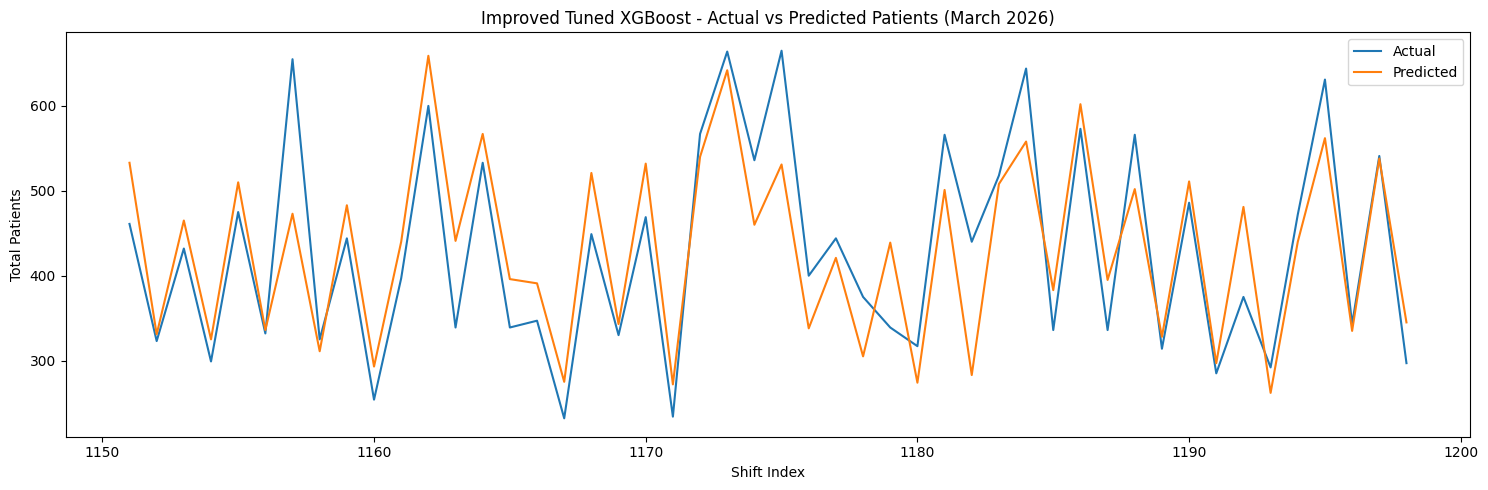

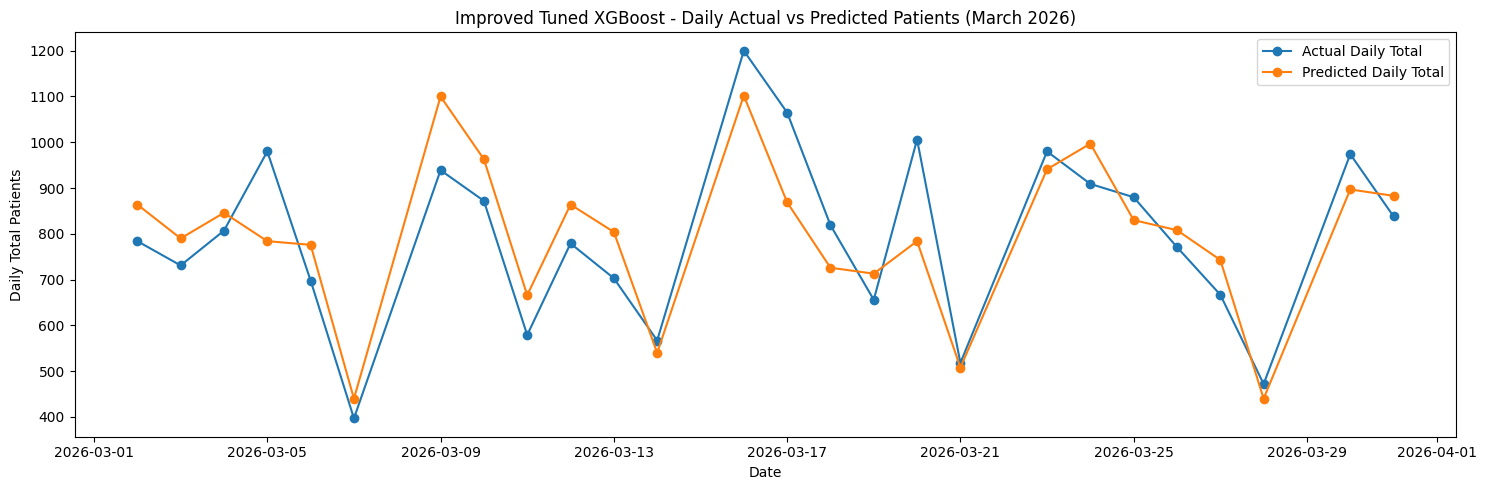

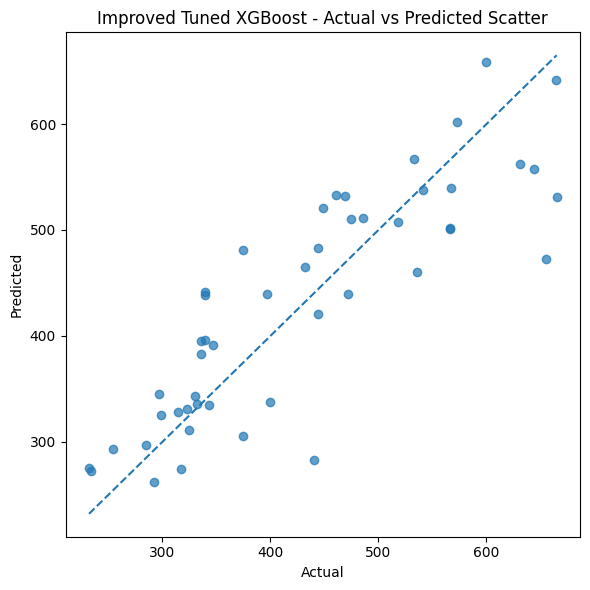

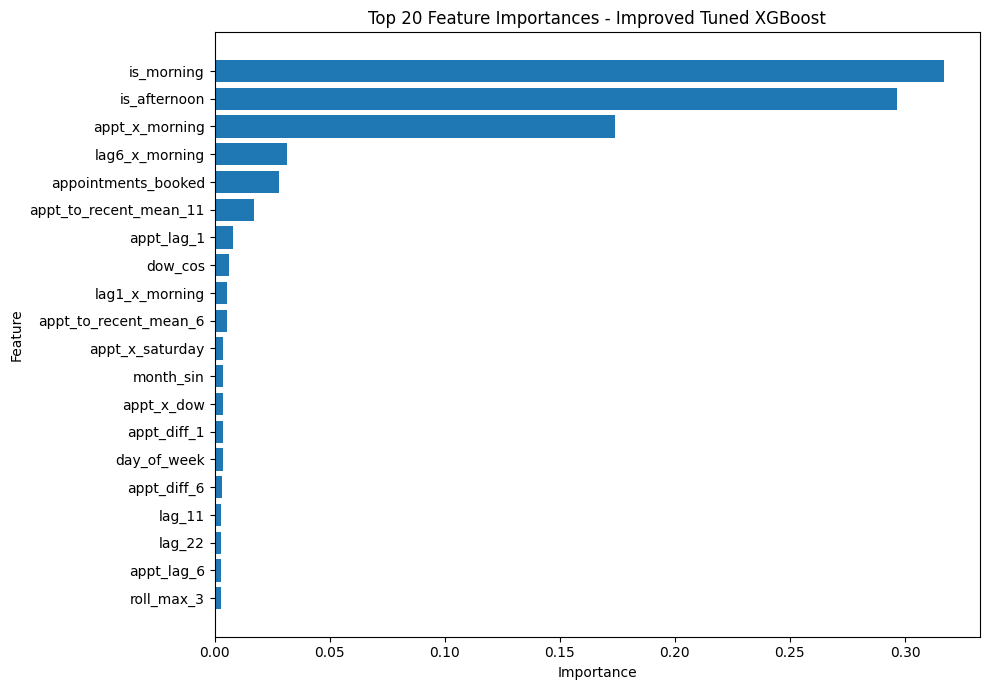


DEMO PREDICTIONS
Case 1:
473
325
325

Case 2 (booking tăng):
550

Saved files:
- xgboost_tuned_test_predictions_avg750.csv
- xgboost_tuned_feature_importance_avg750.csv
- xgboost_tuned_metrics_avg750.csv


In [ ]:
# ============================================
# IMPROVED XGBOOST WITH FEATURE EXPANSION + TUNING
# File: hospital_forecast_data_avg750.csv
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("hospital_forecast_data_avg750.csv")
df["date"] = pd.to_datetime(df["date"])

shift_order_map = {"Morning": 0, "Afternoon": 1}
df["shift_order"] = df["shift"].map(shift_order_map)

df = df.sort_values(["date", "shift_order"]).reset_index(drop=True)

print("=" * 100)
print("DATA OVERVIEW")
print("=" * 100)
print("Shape:", df.shape)
print(df.head())
print(df.tail())

# =========================
# 2. FEATURE ENGINEERING
# =========================
def add_time_features(data):
    data = data.copy()
    data["date"] = pd.to_datetime(data["date"])

    data["day_of_week"] = data["date"].dt.dayofweek   # Monday=0 ... Saturday=5
    data["month"] = data["date"].dt.month
    data["year"] = data["date"].dt.year
    data["day_of_month"] = data["date"].dt.day
    data["week_of_year"] = data["date"].dt.isocalendar().week.astype(int)
    data["quarter"] = data["date"].dt.quarter

    data["is_morning"] = (data["shift"] == "Morning").astype(int)
    data["is_afternoon"] = (data["shift"] == "Afternoon").astype(int)
    data["is_saturday"] = (data["day_of_week"] == 5).astype(int)

    data["is_month_start"] = data["date"].dt.is_month_start.astype(int)
    data["is_month_end"] = data["date"].dt.is_month_end.astype(int)

    # cyclical encoding
    data["dow_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 6)
    data["dow_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 6)

    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

    return data

df = add_time_features(df)

# =========================
# 3. LAG / ROLLING FEATURES
# =========================
# Weekly structure approximation:
# Mon-Fri = 10 shifts, Sat = 1 shift => 11 steps / week
# We use several lag families to help the model learn richer sequence patterns.

target_lags = [1, 2, 3, 6, 11, 12, 22]
appt_lags = [1, 2, 6, 11]

for lag in target_lags:
    df[f"lag_{lag}"] = df["total_patients"].shift(lag)

for lag in appt_lags:
    df[f"appt_lag_{lag}"] = df["appointments_booked"].shift(lag)

# rolling on target (past only)
for window in [3, 6, 11, 22]:
    df[f"roll_mean_{window}"] = df["total_patients"].shift(1).rolling(window).mean()
    df[f"roll_std_{window}"] = df["total_patients"].shift(1).rolling(window).std()
    df[f"roll_min_{window}"] = df["total_patients"].shift(1).rolling(window).min()
    df[f"roll_max_{window}"] = df["total_patients"].shift(1).rolling(window).max()

# rolling on appointments (past only)
for window in [3, 6, 11]:
    df[f"appt_roll_mean_{window}"] = df["appointments_booked"].shift(1).rolling(window).mean()
    df[f"appt_roll_std_{window}"] = df["appointments_booked"].shift(1).rolling(window).std()

# booking deltas
df["appt_diff_1"] = df["appointments_booked"] - df["appointments_booked"].shift(1)
df["appt_diff_6"] = df["appointments_booked"] - df["appointments_booked"].shift(6)
df["appt_diff_11"] = df["appointments_booked"] - df["appointments_booked"].shift(11)

# recent ratio features (NO LEAKAGE because denominator uses only past rolling target)
df["appt_to_recent_mean_6"] = df["appointments_booked"] / df["roll_mean_6"]
df["appt_to_recent_mean_11"] = df["appointments_booked"] / df["roll_mean_11"]

# interactions
df["appt_x_morning"] = df["appointments_booked"] * df["is_morning"]
df["appt_x_saturday"] = df["appointments_booked"] * df["is_saturday"]
df["appt_x_dow"] = df["appointments_booked"] * df["day_of_week"]

# shift-specific recent demand proxy
df["lag1_x_morning"] = df["lag_1"] * df["is_morning"]
df["lag6_x_morning"] = df["lag_6"] * df["is_morning"]

# drop rows with NA created by lag/rolling
df_model = df.dropna().reset_index(drop=True)

print("\nAfter feature engineering:", df_model.shape)

# =========================
# 4. DEFINE FEATURES
# =========================
feature_cols = [
    # current known driver
    "appointments_booked",

    # calendar / shift
    "is_morning",
    "is_afternoon",
    "is_saturday",
    "day_of_week",
    "month",
    "year",
    "day_of_month",
    "week_of_year",
    "quarter",
    "is_month_start",
    "is_month_end",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",

    # target lags
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_11", "lag_12", "lag_22",

    # appointment lags
    "appt_lag_1", "appt_lag_2", "appt_lag_6", "appt_lag_11",

    # rolling target stats
    "roll_mean_3", "roll_mean_6", "roll_mean_11", "roll_mean_22",
    "roll_std_3", "roll_std_6", "roll_std_11", "roll_std_22",
    "roll_min_3", "roll_min_6", "roll_min_11", "roll_min_22",
    "roll_max_3", "roll_max_6", "roll_max_11", "roll_max_22",

    # rolling appointment stats
    "appt_roll_mean_3", "appt_roll_mean_6", "appt_roll_mean_11",
    "appt_roll_std_3", "appt_roll_std_6", "appt_roll_std_11",

    # booking dynamics
    "appt_diff_1", "appt_diff_6", "appt_diff_11",
    "appt_to_recent_mean_6", "appt_to_recent_mean_11",

    # interactions
    "appt_x_morning", "appt_x_saturday", "appt_x_dow",
    "lag1_x_morning", "lag6_x_morning",
]

target_col = "total_patients"

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
train_df = df_model[df_model["date"] < "2026-03-01"].copy()
test_df = df_model[(df_model["date"] >= "2026-03-01") & (df_model["date"] <= "2026-03-31")].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# =========================
# 6. HYPERPARAMETER TUNING
# =========================
base_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 700, 900, 1200],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "min_child_weight": [1, 2, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

tscv = TimeSeriesSplit(n_splits=4)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\n" + "=" * 100)
print("BEST PARAMS")
print("=" * 100)
print(search.best_params_)

print("\nBest CV score (negative RMSE):", search.best_score_)

# =========================
# 7. EVALUATE ON TEST
# =========================
test_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100
r2 = r2_score(y_test, test_pred)

print("\n" + "=" * 100)
print("TEST METRICS (MARCH 2026)")
print("=" * 100)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.4f}")

# =========================
# 8. FEATURE IMPORTANCE
# =========================
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n" + "=" * 100)
print("TOP FEATURE IMPORTANCE")
print("=" * 100)
print(importance_df.head(25))

# =========================
# 9. COMPARE ACTUAL VS PREDICTED
# =========================
compare_df = test_df[["date", "shift", "appointments_booked", "total_patients"]].copy()
compare_df["predicted_total_patients"] = np.round(test_pred).astype(int)
compare_df["abs_error"] = np.abs(compare_df["total_patients"] - compare_df["predicted_total_patients"])
compare_df["ape_pct"] = compare_df["abs_error"] / compare_df["total_patients"] * 100

print("\n" + "=" * 100)
print("ACTUAL VS PREDICTED SAMPLE")
print("=" * 100)
print(compare_df.head(20))

# =========================
# 10. PLOTS
# =========================
# 10.1 Shift-level actual vs predicted
plt.figure(figsize=(15, 5))
plt.plot(compare_df.index, compare_df["total_patients"], label="Actual")
plt.plot(compare_df.index, compare_df["predicted_total_patients"], label="Predicted")
plt.title("Improved Tuned XGBoost - Actual vs Predicted Patients (March 2026)")
plt.xlabel("Shift Index")
plt.ylabel("Total Patients")
plt.legend()
plt.tight_layout()
plt.show()

# 10.2 Daily aggregation actual vs predicted
daily_compare = (
    compare_df.groupby("date", as_index=False)[["total_patients", "predicted_total_patients"]]
    .sum()
)

plt.figure(figsize=(15, 5))
plt.plot(daily_compare["date"], daily_compare["total_patients"], marker="o", label="Actual Daily Total")
plt.plot(daily_compare["date"], daily_compare["predicted_total_patients"], marker="o", label="Predicted Daily Total")
plt.title("Improved Tuned XGBoost - Daily Actual vs Predicted Patients (March 2026)")
plt.xlabel("Date")
plt.ylabel("Daily Total Patients")
plt.legend()
plt.tight_layout()
plt.show()

# 10.3 Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(compare_df["total_patients"], compare_df["predicted_total_patients"], alpha=0.7)
plt.plot(
    [compare_df["total_patients"].min(), compare_df["total_patients"].max()],
    [compare_df["total_patients"].min(), compare_df["total_patients"].max()],
    linestyle="--"
)
plt.title("Improved Tuned XGBoost - Actual vs Predicted Scatter")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

# 10.4 Feature importance
top_n = 20
top_importance = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title(f"Top {top_n} Feature Importances - Improved Tuned XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# =========================
# 11. FIT FINAL MODEL ON FULL DATA
# =========================
X_full = df_model[feature_cols]
y_full = df_model[target_col]

final_model = XGBRegressor(
    **search.best_params_,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_full, y_full)

# =========================
# 12. PREDICTION FUNCTION
# =========================
def prepare_future_row(history_df, input_date, input_shift, appointments_booked):
    input_date = pd.to_datetime(input_date)

    if input_date.dayofweek == 6:
        raise ValueError("Sunday is not a working day in this dataset.")
    if input_date.dayofweek == 5 and input_shift == "Afternoon":
        raise ValueError("Saturday Afternoon is not a working shift in this dataset.")

    new_row = pd.DataFrame({
        "date": [input_date],
        "shift": [input_shift],
        "appointments_booked": [appointments_booked],
        "shift_order": [shift_order_map[input_shift]]
    })

    temp = pd.concat(
        [
            history_df[["date", "shift", "appointments_booked", "total_patients", "shift_order"]],
            new_row
        ],
        ignore_index=True
    )

    temp = temp.sort_values(["date", "shift_order"]).reset_index(drop=True)
    temp = add_time_features(temp)

    # recreate lag features
    for lag in target_lags:
        temp[f"lag_{lag}"] = temp["total_patients"].shift(lag)

    for lag in appt_lags:
        temp[f"appt_lag_{lag}"] = temp["appointments_booked"].shift(lag)

    for window in [3, 6, 11, 22]:
        temp[f"roll_mean_{window}"] = temp["total_patients"].shift(1).rolling(window).mean()
        temp[f"roll_std_{window}"] = temp["total_patients"].shift(1).rolling(window).std()
        temp[f"roll_min_{window}"] = temp["total_patients"].shift(1).rolling(window).min()
        temp[f"roll_max_{window}"] = temp["total_patients"].shift(1).rolling(window).max()

    for window in [3, 6, 11]:
        temp[f"appt_roll_mean_{window}"] = temp["appointments_booked"].shift(1).rolling(window).mean()
        temp[f"appt_roll_std_{window}"] = temp["appointments_booked"].shift(1).rolling(window).std()

    temp["appt_diff_1"] = temp["appointments_booked"] - temp["appointments_booked"].shift(1)
    temp["appt_diff_6"] = temp["appointments_booked"] - temp["appointments_booked"].shift(6)
    temp["appt_diff_11"] = temp["appointments_booked"] - temp["appointments_booked"].shift(11)

    temp["appt_to_recent_mean_6"] = temp["appointments_booked"] / temp["roll_mean_6"]
    temp["appt_to_recent_mean_11"] = temp["appointments_booked"] / temp["roll_mean_11"]

    temp["appt_x_morning"] = temp["appointments_booked"] * temp["is_morning"]
    temp["appt_x_saturday"] = temp["appointments_booked"] * temp["is_saturday"]
    temp["appt_x_dow"] = temp["appointments_booked"] * temp["day_of_week"]

    temp["lag1_x_morning"] = temp["lag_1"] * temp["is_morning"]
    temp["lag6_x_morning"] = temp["lag_6"] * temp["is_morning"]

    predict_row = temp.iloc[[-1]].copy()

    for col in feature_cols:
        if predict_row[col].isna().any():
            predict_row[col] = predict_row[col].fillna(df_model[col].median())

    return predict_row[feature_cols]

def predict_patient_volume(input_date, input_shift, appointments_booked):
    future_X = prepare_future_row(
        history_df=df_model,
        input_date=input_date,
        input_shift=input_shift,
        appointments_booked=appointments_booked
    )
    pred = final_model.predict(future_X)[0]
    return int(round(max(0, pred)))

# =========================
# 13. DEMO
# =========================
print("\n" + "=" * 100)
print("DEMO PREDICTIONS")
print("=" * 100)

print("Case 1:")
print(predict_patient_volume("2026-04-15", "Morning", 120))
print(predict_patient_volume("2026-04-15", "Morning", 10))
print(predict_patient_volume("2026-04-15", "Morning", 0))

print("\nCase 2 (booking tăng):")
print(predict_patient_volume("2026-04-15", "Morning", 150))

# =========================
# 14. SAVE OUTPUTS
# =========================
compare_df.to_csv("xgboost_tuned_test_predictions_avg750.csv", index=False)
importance_df.to_csv("xgboost_tuned_feature_importance_avg750.csv", index=False)

metrics_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "MAPE", "R2"],
    "value": [mae, rmse, mape, r2]
})
metrics_df.to_csv("xgboost_tuned_metrics_avg750.csv", index=False)

print("\nSaved files:")
print("- xgboost_tuned_test_predictions_avg750.csv")
print("- xgboost_tuned_feature_importance_avg750.csv")
print("- xgboost_tuned_metrics_avg750.csv")

## RANDOM FOREST

DATA OVERVIEW
Shape: (1221, 5)
        date      shift  appointments_booked  total_patients  shift_order
0 2024-01-02    Morning                  137             489            0
1 2024-01-02  Afternoon                   58             438            1
2 2024-01-03    Morning                  121             503            0
3 2024-01-03  Afternoon                   60             288            1
4 2024-01-04    Morning                  112             566            0
           date      shift  appointments_booked  total_patients  shift_order
1216 2026-03-28    Morning                   74             472            0
1217 2026-03-30    Morning                  124             631            0
1218 2026-03-30  Afternoon                   92             343            1
1219 2026-03-31    Morning                  139             541            0
1220 2026-03-31  Afternoon                   66             297            1

After feature engineering: (1199, 63)

Train shape: (1151, 59)

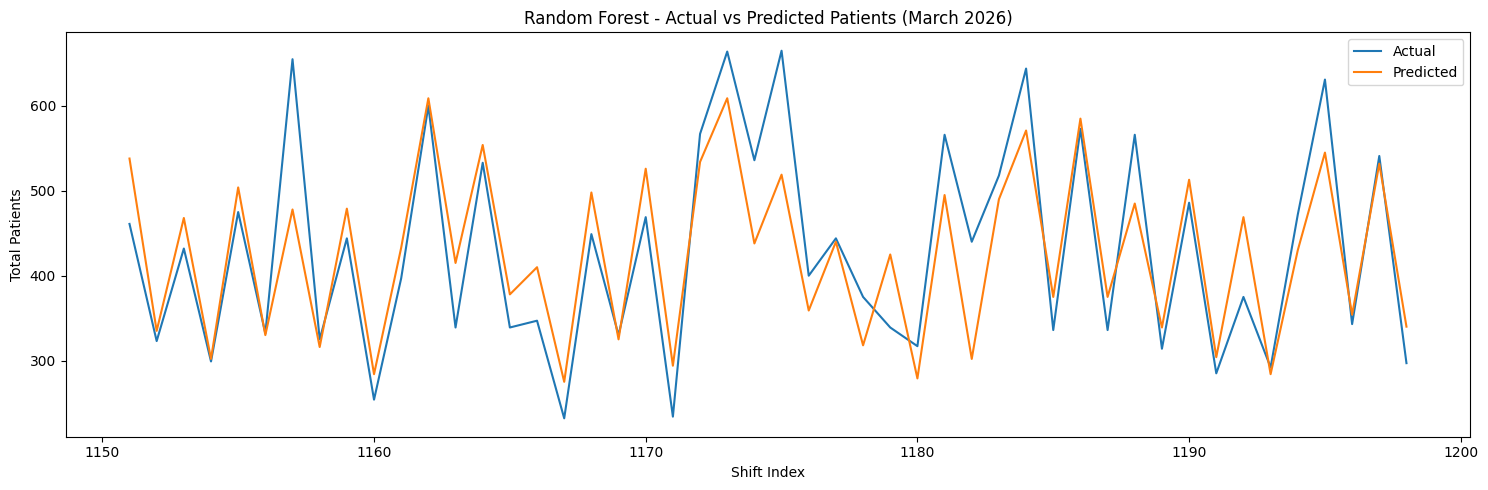

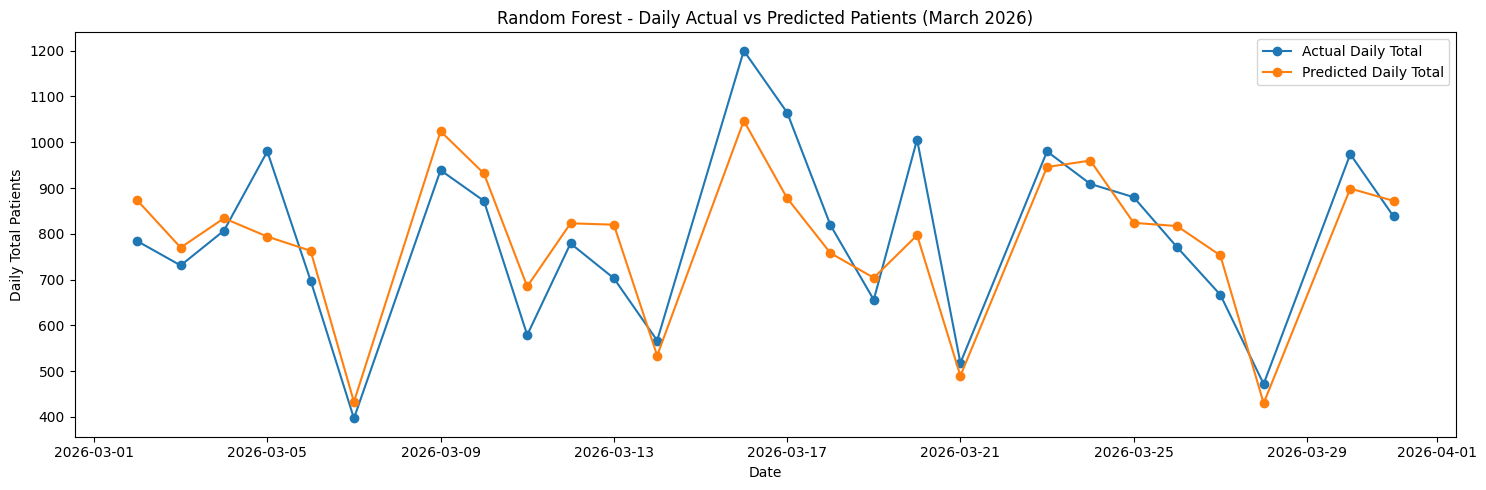

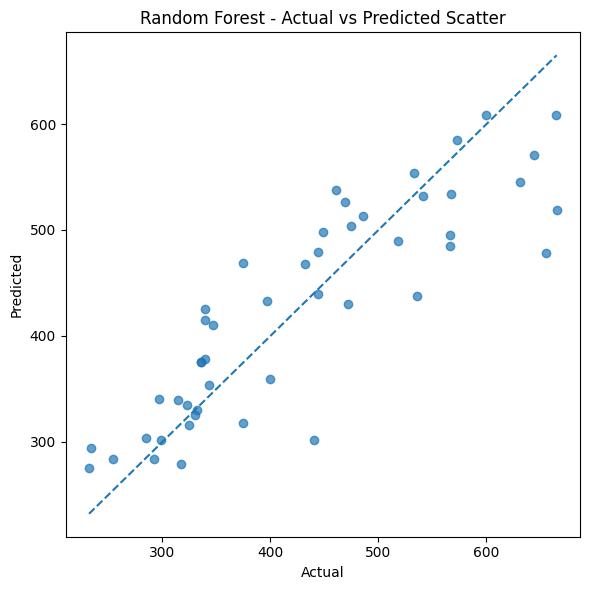

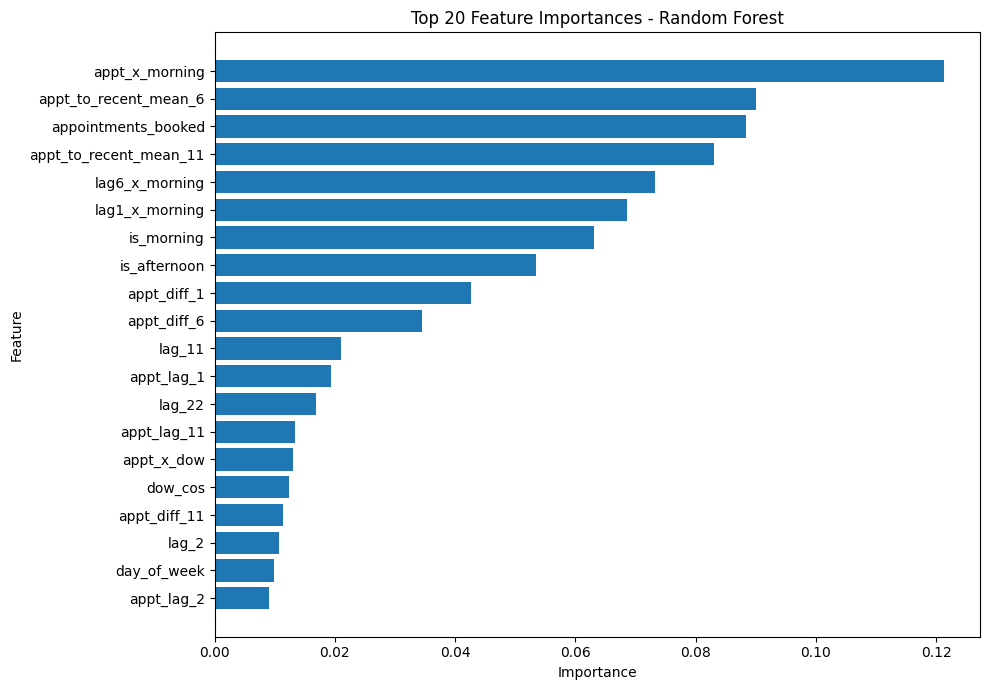


DEMO PREDICTIONS - RANDOM FOREST
Case 1:
487
359
360

Case 2 (booking tăng):
542

Saved files:
- random_forest_test_predictions_avg750.csv
- random_forest_feature_importance_avg750.csv
- random_forest_metrics_avg750.csv


In [ ]:
# ============================================
# RANDOM FOREST WITH FEATURE EXPANSION + TUNING
# File: hospital_forecast_data_avg750.csv
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("hospital_forecast_data_avg750.csv")
df["date"] = pd.to_datetime(df["date"])

shift_order_map = {"Morning": 0, "Afternoon": 1}
df["shift_order"] = df["shift"].map(shift_order_map)
df = df.sort_values(["date", "shift_order"]).reset_index(drop=True)

print("=" * 100)
print("DATA OVERVIEW")
print("=" * 100)
print("Shape:", df.shape)
print(df.head())
print(df.tail())

# =========================
# 2. FEATURE ENGINEERING
# =========================
def add_time_features(data):
    data = data.copy()
    data["date"] = pd.to_datetime(data["date"])

    data["day_of_week"] = data["date"].dt.dayofweek   # Monday=0 ... Saturday=5
    data["month"] = data["date"].dt.month
    data["year"] = data["date"].dt.year
    data["day_of_month"] = data["date"].dt.day
    data["week_of_year"] = data["date"].dt.isocalendar().week.astype(int)
    data["quarter"] = data["date"].dt.quarter

    data["is_morning"] = (data["shift"] == "Morning").astype(int)
    data["is_afternoon"] = (data["shift"] == "Afternoon").astype(int)
    data["is_saturday"] = (data["day_of_week"] == 5).astype(int)

    data["is_month_start"] = data["date"].dt.is_month_start.astype(int)
    data["is_month_end"] = data["date"].dt.is_month_end.astype(int)

    data["dow_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 6)
    data["dow_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 6)

    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

    return data

df = add_time_features(df)

# =========================
# 3. LAG / ROLLING FEATURES
# =========================
target_lags = [1, 2, 3, 6, 11, 12, 22]
appt_lags = [1, 2, 6, 11]

for lag in target_lags:
    df[f"lag_{lag}"] = df["total_patients"].shift(lag)

for lag in appt_lags:
    df[f"appt_lag_{lag}"] = df["appointments_booked"].shift(lag)

for window in [3, 6, 11, 22]:
    df[f"roll_mean_{window}"] = df["total_patients"].shift(1).rolling(window).mean()
    df[f"roll_std_{window}"] = df["total_patients"].shift(1).rolling(window).std()
    df[f"roll_min_{window}"] = df["total_patients"].shift(1).rolling(window).min()
    df[f"roll_max_{window}"] = df["total_patients"].shift(1).rolling(window).max()

for window in [3, 6, 11]:
    df[f"appt_roll_mean_{window}"] = df["appointments_booked"].shift(1).rolling(window).mean()
    df[f"appt_roll_std_{window}"] = df["appointments_booked"].shift(1).rolling(window).std()

df["appt_diff_1"] = df["appointments_booked"] - df["appointments_booked"].shift(1)
df["appt_diff_6"] = df["appointments_booked"] - df["appointments_booked"].shift(6)
df["appt_diff_11"] = df["appointments_booked"] - df["appointments_booked"].shift(11)

df["appt_to_recent_mean_6"] = df["appointments_booked"] / df["roll_mean_6"]
df["appt_to_recent_mean_11"] = df["appointments_booked"] / df["roll_mean_11"]

df["appt_x_morning"] = df["appointments_booked"] * df["is_morning"]
df["appt_x_saturday"] = df["appointments_booked"] * df["is_saturday"]
df["appt_x_dow"] = df["appointments_booked"] * df["day_of_week"]

df["lag1_x_morning"] = df["lag_1"] * df["is_morning"]
df["lag6_x_morning"] = df["lag_6"] * df["is_morning"]

df_model = df.dropna().reset_index(drop=True)

print("\nAfter feature engineering:", df_model.shape)

# =========================
# 4. DEFINE FEATURES
# =========================
feature_cols = [
    "appointments_booked",

    "is_morning",
    "is_afternoon",
    "is_saturday",
    "day_of_week",
    "month",
    "year",
    "day_of_month",
    "week_of_year",
    "quarter",
    "is_month_start",
    "is_month_end",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",

    "lag_1", "lag_2", "lag_3", "lag_6", "lag_11", "lag_12", "lag_22",

    "appt_lag_1", "appt_lag_2", "appt_lag_6", "appt_lag_11",

    "roll_mean_3", "roll_mean_6", "roll_mean_11", "roll_mean_22",
    "roll_std_3", "roll_std_6", "roll_std_11", "roll_std_22",
    "roll_min_3", "roll_min_6", "roll_min_11", "roll_min_22",
    "roll_max_3", "roll_max_6", "roll_max_11", "roll_max_22",

    "appt_roll_mean_3", "appt_roll_mean_6", "appt_roll_mean_11",
    "appt_roll_std_3", "appt_roll_std_6", "appt_roll_std_11",

    "appt_diff_1", "appt_diff_6", "appt_diff_11",
    "appt_to_recent_mean_6", "appt_to_recent_mean_11",

    "appt_x_morning", "appt_x_saturday", "appt_x_dow",
    "lag1_x_morning", "lag6_x_morning",
]

target_col = "total_patients"

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
train_df = df_model[df_model["date"] < "2026-03-01"].copy()
test_df = df_model[(df_model["date"] >= "2026-03-01") & (df_model["date"] <= "2026-03-31")].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# =========================
# 6. HYPERPARAMETER TUNING
# =========================
base_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 300, 500, 700, 1000],
    "max_depth": [5, 8, 10, 12, 15, 20, None],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.7, 0.9],
    "bootstrap": [True],
    "max_samples": [0.6, 0.7, 0.8, 0.9, None]
}

tscv = TimeSeriesSplit(n_splits=4)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\n" + "=" * 100)
print("BEST PARAMS")
print("=" * 100)
print(search.best_params_)
print("\nBest CV score (negative RMSE):", search.best_score_)
print("Best RMSE:", -search.best_score_)

# =========================
# 7. EVALUATE ON TEST
# =========================
test_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100
r2 = r2_score(y_test, test_pred)

print("\n" + "=" * 100)
print("TEST METRICS (MARCH 2026)")
print("=" * 100)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.4f}")

# =========================
# 8. FEATURE IMPORTANCE
# =========================
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n" + "=" * 100)
print("TOP FEATURE IMPORTANCE")
print("=" * 100)
print(importance_df.head(25))

# =========================
# 9. COMPARE ACTUAL VS PREDICTED
# =========================
compare_df = test_df[["date", "shift", "appointments_booked", "total_patients"]].copy()
compare_df["predicted_total_patients"] = np.round(test_pred).astype(int)
compare_df["abs_error"] = np.abs(compare_df["total_patients"] - compare_df["predicted_total_patients"])
compare_df["ape_pct"] = compare_df["abs_error"] / compare_df["total_patients"] * 100

print("\n" + "=" * 100)
print("ACTUAL VS PREDICTED SAMPLE")
print("=" * 100)
print(compare_df.head(20))

# =========================
# 10. PLOTS
# =========================
plt.figure(figsize=(15, 5))
plt.plot(compare_df.index, compare_df["total_patients"], label="Actual")
plt.plot(compare_df.index, compare_df["predicted_total_patients"], label="Predicted")
plt.title("Random Forest - Actual vs Predicted Patients (March 2026)")
plt.xlabel("Shift Index")
plt.ylabel("Total Patients")
plt.legend()
plt.tight_layout()
plt.show()

daily_compare = (
    compare_df.groupby("date", as_index=False)[["total_patients", "predicted_total_patients"]]
    .sum()
)

plt.figure(figsize=(15, 5))
plt.plot(daily_compare["date"], daily_compare["total_patients"], marker="o", label="Actual Daily Total")
plt.plot(daily_compare["date"], daily_compare["predicted_total_patients"], marker="o", label="Predicted Daily Total")
plt.title("Random Forest - Daily Actual vs Predicted Patients (March 2026)")
plt.xlabel("Date")
plt.ylabel("Daily Total Patients")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(compare_df["total_patients"], compare_df["predicted_total_patients"], alpha=0.7)
plt.plot(
    [compare_df["total_patients"].min(), compare_df["total_patients"].max()],
    [compare_df["total_patients"].min(), compare_df["total_patients"].max()],
    linestyle="--"
)
plt.title("Random Forest - Actual vs Predicted Scatter")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

top_n = 20
top_importance = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title(f"Top {top_n} Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# =========================
# 11. FIT FINAL MODEL ON FULL DATA
# =========================
X_full = df_model[feature_cols]
y_full = df_model[target_col]

final_model = RandomForestRegressor(
    **search.best_params_,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_full, y_full)

# =========================
# 12. PREDICTION FUNCTION
# =========================
def prepare_future_row(history_df, input_date, input_shift, appointments_booked):
    input_date = pd.to_datetime(input_date)

    if input_date.dayofweek == 6:
        raise ValueError("Sunday is not a working day in this dataset.")
    if input_date.dayofweek == 5 and input_shift == "Afternoon":
        raise ValueError("Saturday Afternoon is not a working shift in this dataset.")

    new_row = pd.DataFrame({
        "date": [input_date],
        "shift": [input_shift],
        "appointments_booked": [appointments_booked],
        "shift_order": [shift_order_map[input_shift]]
    })

    temp = pd.concat(
        [
            history_df[["date", "shift", "appointments_booked", "total_patients", "shift_order"]],
            new_row
        ],
        ignore_index=True
    )

    temp = temp.sort_values(["date", "shift_order"]).reset_index(drop=True)
    temp = add_time_features(temp)

    for lag in target_lags:
        temp[f"lag_{lag}"] = temp["total_patients"].shift(lag)

    for lag in appt_lags:
        temp[f"appt_lag_{lag}"] = temp["appointments_booked"].shift(lag)

    for window in [3, 6, 11, 22]:
        temp[f"roll_mean_{window}"] = temp["total_patients"].shift(1).rolling(window).mean()
        temp[f"roll_std_{window}"] = temp["total_patients"].shift(1).rolling(window).std()
        temp[f"roll_min_{window}"] = temp["total_patients"].shift(1).rolling(window).min()
        temp[f"roll_max_{window}"] = temp["total_patients"].shift(1).rolling(window).max()

    for window in [3, 6, 11]:
        temp[f"appt_roll_mean_{window}"] = temp["appointments_booked"].shift(1).rolling(window).mean()
        temp[f"appt_roll_std_{window}"] = temp["appointments_booked"].shift(1).rolling(window).std()

    temp["appt_diff_1"] = temp["appointments_booked"] - temp["appointments_booked"].shift(1)
    temp["appt_diff_6"] = temp["appointments_booked"] - temp["appointments_booked"].shift(6)
    temp["appt_diff_11"] = temp["appointments_booked"] - temp["appointments_booked"].shift(11)

    temp["appt_to_recent_mean_6"] = temp["appointments_booked"] / temp["roll_mean_6"]
    temp["appt_to_recent_mean_11"] = temp["appointments_booked"] / temp["roll_mean_11"]

    temp["appt_x_morning"] = temp["appointments_booked"] * temp["is_morning"]
    temp["appt_x_saturday"] = temp["appointments_booked"] * temp["is_saturday"]
    temp["appt_x_dow"] = temp["appointments_booked"] * temp["day_of_week"]

    temp["lag1_x_morning"] = temp["lag_1"] * temp["is_morning"]
    temp["lag6_x_morning"] = temp["lag_6"] * temp["is_morning"]

    predict_row = temp.iloc[[-1]].copy()

    for col in feature_cols:
        if predict_row[col].isna().any():
            predict_row[col] = predict_row[col].fillna(df_model[col].median())

    return predict_row[feature_cols]

def predict_patient_volume_rf(input_date, input_shift, appointments_booked):
    future_X = prepare_future_row(
        history_df=df_model,
        input_date=input_date,
        input_shift=input_shift,
        appointments_booked=appointments_booked
    )
    pred = final_model.predict(future_X)[0]
    return int(round(max(0, pred)))

# =========================
# 13. DEMO
# =========================
print("\n" + "=" * 100)
print("DEMO PREDICTIONS - RANDOM FOREST")
print("=" * 100)

print("Case 1:")
print(predict_patient_volume_rf("2026-04-15", "Morning", 120))
print(predict_patient_volume_rf("2026-04-15", "Morning", 10))
print(predict_patient_volume_rf("2026-04-15", "Morning", 0))

print("\nCase 2 (booking tăng):")
print(predict_patient_volume_rf("2026-04-15", "Morning", 150))

# =========================
# 14. SAVE OUTPUTS
# =========================
compare_df.to_csv("random_forest_test_predictions_avg750.csv", index=False)
importance_df.to_csv("random_forest_feature_importance_avg750.csv", index=False)

metrics_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "MAPE", "R2"],
    "value": [mae, rmse, mape, r2]
})
metrics_df.to_csv("random_forest_metrics_avg750.csv", index=False)

print("\nSaved files:")
print("- random_forest_test_predictions_avg750.csv")
print("- random_forest_feature_importance_avg750.csv")
print("- random_forest_metrics_avg750.csv")

## LSTM

DATA OVERVIEW
Shape: (1221, 5)
        date      shift  appointments_booked  total_patients  shift_order
0 2024-01-02    Morning                  137             489            0
1 2024-01-02  Afternoon                   58             438            1
2 2024-01-03    Morning                  121             503            0
3 2024-01-03  Afternoon                   60             288            1
4 2024-01-04    Morning                  112             566            0
           date      shift  appointments_booked  total_patients  shift_order
1216 2026-03-28    Morning                   74             472            0
1217 2026-03-30    Morning                  124             631            0
1218 2026-03-30  Afternoon                   92             343            1
1219 2026-03-31    Morning                  139             541            0
1220 2026-03-31  Afternoon                   66             297            1
SEQUENCE SHAPES
X_train_seq: (1150, 12, 25)
y_train_seq: (1150,

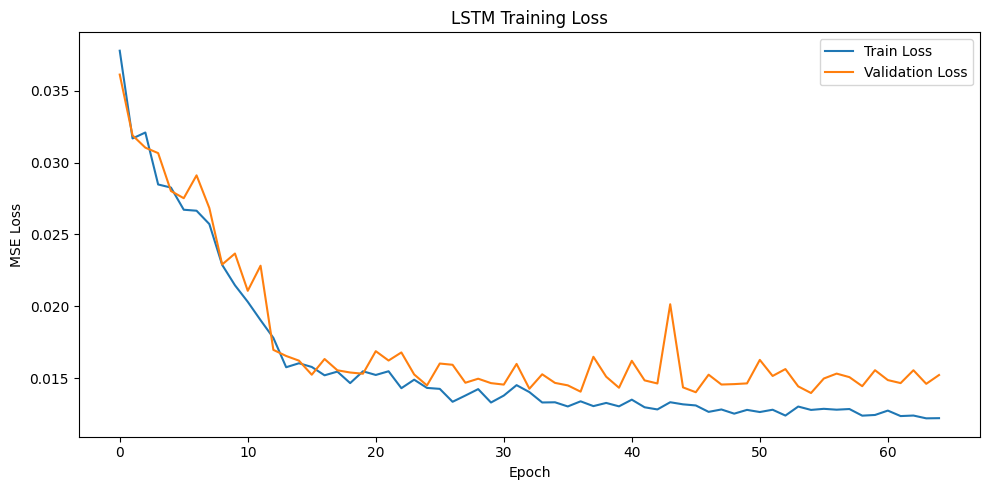

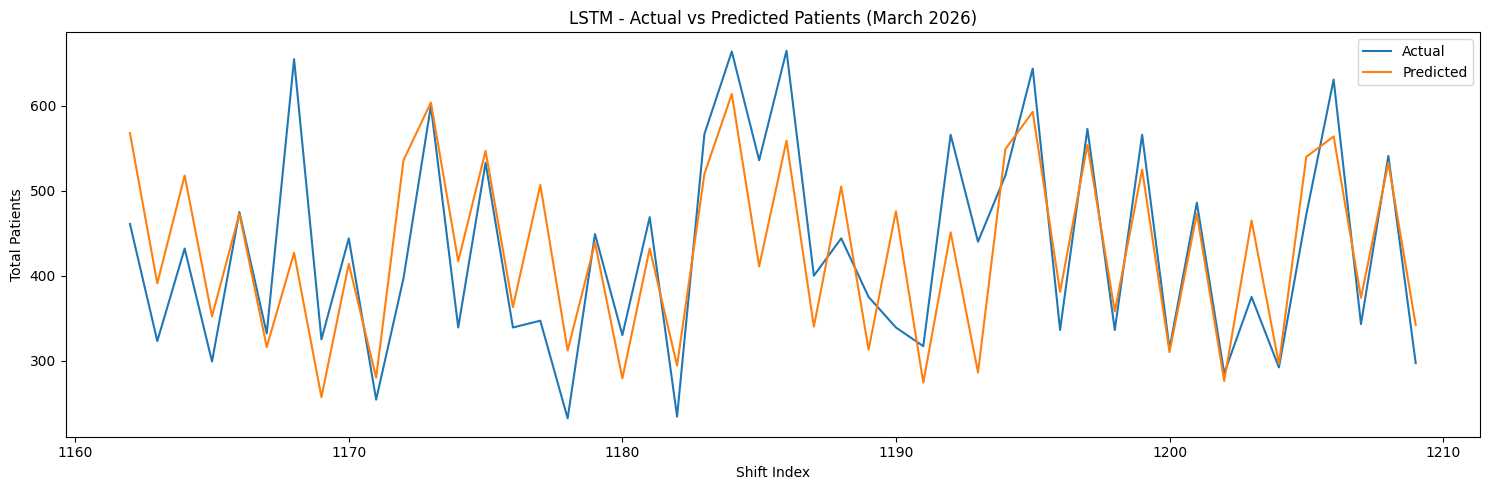

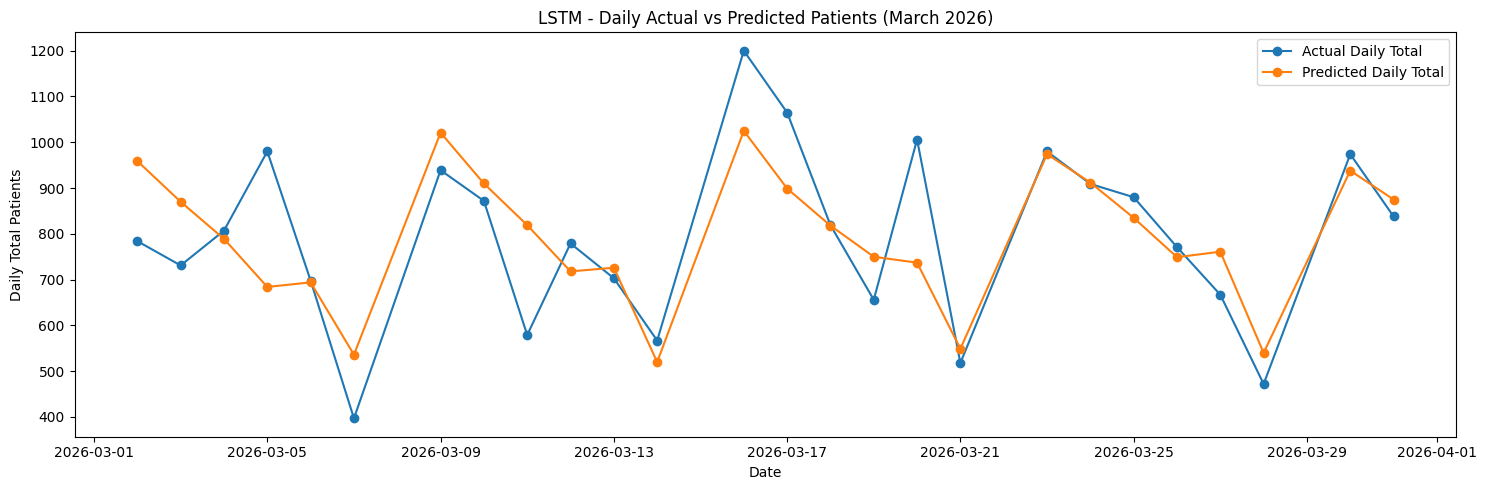

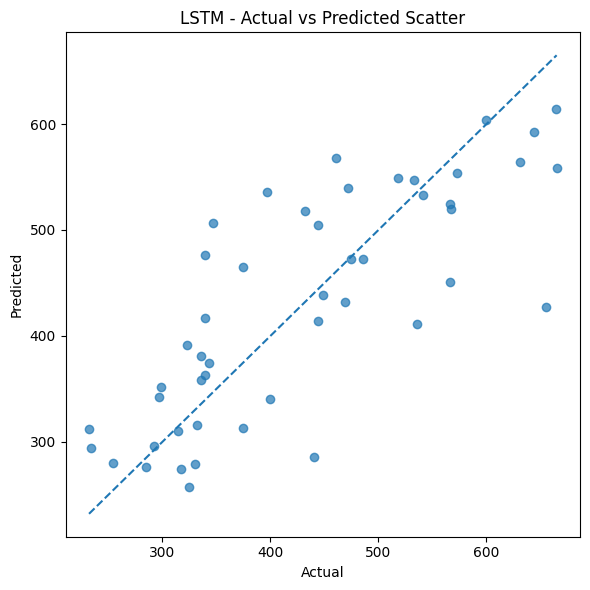


DEMO PREDICTIONS - LSTM
Case 1:


284
259
257

Case 2 (booking tăng):
291

Saved files:
- lstm_test_predictions_avg750.csv
- lstm_metrics_avg750.csv


In [ ]:
# ============================================
# LSTM FORECASTING - SMART HOSPITAL
# File: hospital_forecast_data_avg750.csv
# Target: total_patients
# Features: appointments_booked + calendar + shift
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("hospital_forecast_data_avg750.csv")
df["date"] = pd.to_datetime(df["date"])

shift_order_map = {"Morning": 0, "Afternoon": 1}
df["shift_order"] = df["shift"].map(shift_order_map)
df = df.sort_values(["date", "shift_order"]).reset_index(drop=True)

print("=" * 100)
print("DATA OVERVIEW")
print("=" * 100)
print("Shape:", df.shape)
print(df.head())
print(df.tail())

# =========================
# 2. FEATURE ENGINEERING
# =========================
df["day_of_week"] = df["date"].dt.dayofweek   # Mon=0 ... Sat=5
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter

df["is_morning"] = (df["shift"] == "Morning").astype(int)
df["is_afternoon"] = (df["shift"] == "Afternoon").astype(int)
df["is_saturday"] = (df["day_of_week"] == 5).astype(int)

# cyclical features
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 6)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 6)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# lag features that are known from history only
df["lag_1"] = df["total_patients"].shift(1)
df["lag_2"] = df["total_patients"].shift(2)
df["lag_6"] = df["total_patients"].shift(6)
df["lag_11"] = df["total_patients"].shift(11)

# rolling features from past only
df["roll_mean_3"] = df["total_patients"].shift(1).rolling(3).mean()
df["roll_mean_6"] = df["total_patients"].shift(1).rolling(6).mean()
df["roll_std_3"] = df["total_patients"].shift(1).rolling(3).std()
df["roll_std_6"] = df["total_patients"].shift(1).rolling(6).std()

df["appt_lag_1"] = df["appointments_booked"].shift(1)
df["appt_lag_6"] = df["appointments_booked"].shift(6)
df["appt_diff_1"] = df["appointments_booked"] - df["appointments_booked"].shift(1)

df = df.dropna().reset_index(drop=True)

# =========================
# 3. DEFINE FEATURES
# =========================
feature_cols = [
    "appointments_booked",
    "day_of_week",
    "month",
    "year",
    "day_of_month",
    "week_of_year",
    "quarter",
    "is_morning",
    "is_afternoon",
    "is_saturday",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_2",
    "lag_6",
    "lag_11",
    "roll_mean_3",
    "roll_mean_6",
    "roll_std_3",
    "roll_std_6",
    "appt_lag_1",
    "appt_lag_6",
    "appt_diff_1"
]

target_col = "total_patients"

# keep original for later
model_df = df[["date", "shift", "total_patients"] + feature_cols].copy()

# =========================
# 4. TRAIN / TEST SPLIT
# =========================
train_df = model_df[model_df["date"] < "2026-03-01"].copy()
test_df = model_df[(model_df["date"] >= "2026-03-01") & (model_df["date"] <= "2026-03-31")].copy()

# =========================
# 5. SCALE FEATURES
# =========================
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_raw = train_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()

y_train_raw = train_df[[target_col]].copy()
y_test_raw = test_df[[target_col]].copy()

X_train_scaled = feature_scaler.fit_transform(X_train_raw)
X_test_scaled = feature_scaler.transform(X_test_raw)

y_train_scaled = target_scaler.fit_transform(y_train_raw)
y_test_scaled = target_scaler.transform(y_test_raw)

# =========================
# 6. BUILD SEQUENCES
# =========================
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 12

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQ_LEN)

# For test, prepend tail of train to preserve sequence continuity
X_all_for_test = np.vstack([X_train_scaled[-SEQ_LEN:], X_test_scaled])
y_all_for_test = np.vstack([y_train_scaled[-SEQ_LEN:], y_test_scaled])

X_test_seq, y_test_seq = create_sequences(X_all_for_test, y_all_for_test, SEQ_LEN)

print("=" * 100)
print("SEQUENCE SHAPES")
print("=" * 100)
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print("y_test_seq :", y_test_seq.shape)

# =========================
# 7. BUILD LSTM MODEL
# =========================
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 8. PREDICT ON TEST
# =========================
test_pred_scaled = model.predict(X_test_seq)
test_pred = target_scaler.inverse_transform(test_pred_scaled).flatten()
y_test_actual = target_scaler.inverse_transform(y_test_seq).flatten()

# =========================
# 9. EVALUATE
# =========================
mae = mean_absolute_error(y_test_actual, test_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))
mape = np.mean(np.abs((y_test_actual - test_pred) / y_test_actual)) * 100
r2 = r2_score(y_test_actual, test_pred)

print("\n" + "=" * 100)
print("TEST METRICS (MARCH 2026)")
print("=" * 100)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.4f}")

# =========================
# 10. COMPARE ACTUAL VS PREDICTED
# =========================
compare_df = test_df.iloc[:len(test_pred)][["date", "shift", "appointments_booked", "total_patients"]].copy()
compare_df["predicted_total_patients"] = np.round(test_pred).astype(int)
compare_df["abs_error"] = np.abs(compare_df["total_patients"] - compare_df["predicted_total_patients"])
compare_df["ape_pct"] = compare_df["abs_error"] / compare_df["total_patients"] * 100

print("\n" + "=" * 100)
print("ACTUAL VS PREDICTED SAMPLE")
print("=" * 100)
print(compare_df.head(20))

# =========================
# 11. PLOTS
# =========================
# Loss curve
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Shift-level actual vs predicted
plt.figure(figsize=(15, 5))
plt.plot(compare_df.index, compare_df["total_patients"], label="Actual")
plt.plot(compare_df.index, compare_df["predicted_total_patients"], label="Predicted")
plt.title("LSTM - Actual vs Predicted Patients (March 2026)")
plt.xlabel("Shift Index")
plt.ylabel("Total Patients")
plt.legend()
plt.tight_layout()
plt.show()

# Daily level actual vs predicted
daily_compare = (
    compare_df.groupby("date", as_index=False)[["total_patients", "predicted_total_patients"]]
    .sum()
)

plt.figure(figsize=(15, 5))
plt.plot(daily_compare["date"], daily_compare["total_patients"], marker="o", label="Actual Daily Total")
plt.plot(daily_compare["date"], daily_compare["predicted_total_patients"], marker="o", label="Predicted Daily Total")
plt.title("LSTM - Daily Actual vs Predicted Patients (March 2026)")
plt.xlabel("Date")
plt.ylabel("Daily Total Patients")
plt.legend()
plt.tight_layout()
plt.show()

# Scatter
plt.figure(figsize=(6, 6))
plt.scatter(compare_df["total_patients"], compare_df["predicted_total_patients"], alpha=0.7)
plt.plot(
    [compare_df["total_patients"].min(), compare_df["total_patients"].max()],
    [compare_df["total_patients"].min(), compare_df["total_patients"].max()],
    linestyle="--"
)
plt.title("LSTM - Actual vs Predicted Scatter")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

# =========================
# 12. TRAIN FINAL MODEL ON FULL DATA
# =========================
X_full_raw = model_df[feature_cols].copy()
y_full_raw = model_df[[target_col]].copy()

X_full_scaled = feature_scaler.fit_transform(X_full_raw)
y_full_scaled = target_scaler.fit_transform(y_full_raw)

X_full_seq, y_full_seq = create_sequences(X_full_scaled, y_full_scaled, SEQ_LEN)

final_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_full_seq.shape[1], X_full_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

final_model.compile(optimizer="adam", loss="mse")

final_model.fit(
    X_full_seq,
    y_full_seq,
    epochs=max(10, len(history.history["loss"])),
    batch_size=32,
    verbose=0
)

# =========================
# 13. SINGLE FUTURE PREDICTION FUNCTION
# =========================
def build_future_features(history_df, input_date, input_shift, appointments_booked):
    input_date = pd.to_datetime(input_date)

    if input_date.dayofweek == 6:
        raise ValueError("Sunday is not a working day in this dataset.")
    if input_date.dayofweek == 5 and input_shift == "Afternoon":
        raise ValueError("Saturday Afternoon is not a working shift in this dataset.")

    temp = history_df.copy()

    new_row = {
        "date": input_date,
        "shift": input_shift,
        "appointments_booked": appointments_booked,
        "total_patients": np.nan
    }

    temp = pd.concat([temp, pd.DataFrame([new_row])], ignore_index=True)

    temp["day_of_week"] = temp["date"].dt.dayofweek
    temp["month"] = temp["date"].dt.month
    temp["year"] = temp["date"].dt.year
    temp["day_of_month"] = temp["date"].dt.day
    temp["week_of_year"] = temp["date"].dt.isocalendar().week.astype(int)
    temp["quarter"] = temp["date"].dt.quarter

    temp["is_morning"] = (temp["shift"] == "Morning").astype(int)
    temp["is_afternoon"] = (temp["shift"] == "Afternoon").astype(int)
    temp["is_saturday"] = (temp["day_of_week"] == 5).astype(int)

    temp["dow_sin"] = np.sin(2 * np.pi * temp["day_of_week"] / 6)
    temp["dow_cos"] = np.cos(2 * np.pi * temp["day_of_week"] / 6)
    temp["month_sin"] = np.sin(2 * np.pi * temp["month"] / 12)
    temp["month_cos"] = np.cos(2 * np.pi * temp["month"] / 12)

    temp["lag_1"] = temp["total_patients"].shift(1)
    temp["lag_2"] = temp["total_patients"].shift(2)
    temp["lag_6"] = temp["total_patients"].shift(6)
    temp["lag_11"] = temp["total_patients"].shift(11)

    temp["roll_mean_3"] = temp["total_patients"].shift(1).rolling(3).mean()
    temp["roll_mean_6"] = temp["total_patients"].shift(1).rolling(6).mean()
    temp["roll_std_3"] = temp["total_patients"].shift(1).rolling(3).std()
    temp["roll_std_6"] = temp["total_patients"].shift(1).rolling(6).std()

    temp["appt_lag_1"] = temp["appointments_booked"].shift(1)
    temp["appt_lag_6"] = temp["appointments_booked"].shift(6)
    temp["appt_diff_1"] = temp["appointments_booked"] - temp["appointments_booked"].shift(1)

    future_row = temp.iloc[[-1]].copy()

    for col in feature_cols:
        if future_row[col].isna().any():
            future_row[col] = future_row[col].fillna(model_df[col].median())

    return future_row[feature_cols]

def predict_patient_volume_lstm(input_date, input_shift, appointments_booked):
    future_features = build_future_features(
        history_df=model_df[["date", "shift", "appointments_booked", "total_patients"]].copy(),
        input_date=input_date,
        input_shift=input_shift,
        appointments_booked=appointments_booked
    )

    # Need a full sequence, so take last SEQ_LEN-1 rows from history + future row
    hist_features = model_df[feature_cols].copy().tail(SEQ_LEN - 1)
    seq_df = pd.concat([hist_features, future_features], ignore_index=True)

    seq_scaled = feature_scaler.transform(seq_df)
    seq_scaled = np.expand_dims(seq_scaled, axis=0)

    pred_scaled = final_model.predict(seq_scaled, verbose=0)
    pred = target_scaler.inverse_transform(pred_scaled)[0][0]

    return int(round(max(0, pred)))

# =========================
# 14. DEMO
# =========================
print("\n" + "=" * 100)
print("DEMO PREDICTIONS - LSTM")
print("=" * 100)

print("Case 1:")
print(predict_patient_volume_lstm("2026-04-15", "Morning", 120))
print(predict_patient_volume_lstm("2026-04-15", "Morning", 10))
print(predict_patient_volume_lstm("2026-04-15", "Morning", 0))

print("\nCase 2 (booking tăng):")
print(predict_patient_volume_lstm("2026-04-15", "Morning", 150))

# =========================
# 15. SAVE OUTPUTS
# =========================
compare_df.to_csv("lstm_test_predictions_avg750.csv", index=False)

metrics_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "MAPE", "R2"],
    "value": [mae, rmse, mape, r2]
})
metrics_df.to_csv("lstm_metrics_avg750.csv", index=False)

print("\nSaved files:")
print("- lstm_test_predictions_avg750.csv")
print("- lstm_metrics_avg750.csv")

## Evaluation Table

In [ ]:
import pandas as pd

# Tạo dữ liệu
data = {
    "Model": ["SARIMAX", "XGBOOST", "RANDOM FOREST", "LSTM"],
    "MAE": [53.48, 50.90, 47.32, 59.31],
    "RMSE": [72.22, 63.54, 60.58, 76.30],
    "MAPE (%)": [12.43, 12.06, 11.04, 14.52],
    "R2": [0.6527, 0.7312, 0.7557, 0.6123]
}

# Tạo DataFrame
df_compare = pd.DataFrame(data)

# Sắp xếp theo RMSE (nhỏ -> tốt)
df_compare = df_compare.sort_values(by="RMSE")

# Reset index cho đẹp
df_compare = df_compare.reset_index(drop=True)

# Hiển thị bảng
df_compare

,Model,MAE,RMSE,MAPE (%),R2
0,RANDOM FOREST,47.32,60.58,11.04,0.7557
1,XGBOOST,50.90,63.54,12.06,0.7312
2,SARIMAX,53.48,72.22,12.43,0.6527
3,LSTM,59.31,76.30,14.52,0.6123
